# RetailCo Demand Model — Experimentos e Evidências

Este notebook contém toda a investigação técnica por trás da correção do modelo de forecast do RetailCo, organizada **por pergunta respondida**, não em ordem cronológica de execução. Serve como fonte de evidência para qualquer pergunta técnica da banca.

**Seções:**
1. Carregar dados e engenharia de features
2. Diagnóstico do Problema 2 (causa raiz do sinal errado do SHAP)
3. Normalização de preço vs restrição monotônica
4. Pooling vs SKU-level
5. Bake-off de modelos (LightGBM, XGBoost, GAM, Ensemble empilhado)
6. Busca bayesiana de hiperparâmetros (Optuna)
7. Validação recursiva (multi-step) e degradação por horizonte
8. Teste de restrição nos modelos vencedores problemáticos

> Testes de significância estatística (elasticidade de preço, Promoção vs Publicidade) estão no notebook separado `Statistical_Significance_Tests.ipynb`.

> Requisitos: `pip install lightgbm xgboost pygam shap optuna pandas numpy scikit-learn matplotlib openpyxl`


## 0. Libraries

In [110]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
import shap
import optuna
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l, f
from scipy import stats

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")


## 0.1. Load Data

Edite `DATA_PATH` abaixo para o caminho do seu arquivo.

In [111]:
DATA_PATH = "Business_Case_Data_Set.xlsx"
OUTDIR = Path("output")
OUTDIR.mkdir(exist_ok=True, parents=True)

CATEGORY_MAP = {
    "Natural Juice 1L": "Beverages",
    "Flavored Water 500ml": "Beverages",
    "Energy Drink 350ml": "Beverages",
    "Whole Grain Crackers 200g": "Snacks",
    "Cereal Bar 50g": "Snacks",
}

xl = pd.ExcelFile(DATA_PATH)
ext = xl.parse("Table 1 - External Variables")
actual = xl.parse("Table 2 - Sell In")

raw = ext.merge(actual, on=["Week", "Product", "Channel"], how="inner")
raw["Week"] = pd.to_datetime(raw["Week"])
raw["Category"] = raw["Product"].map(CATEGORY_MAP)
raw = raw.sort_values(["Product", "Channel", "Week"]).reset_index(drop=True)

# Trend term for the GAM: position (0,1,2,...) within each Product x Channel
# series, computed on the FULL raw series (before feature engineering drops
# the early rows with no lag history).
raw["Week_Index"] = raw.groupby(["Product", "Channel"]).cumcount()

print(f"{len(raw)} rows loaded, {raw['Week'].min().date()} to {raw['Week'].max().date()}")
raw.head()


2340 rows loaded, 2023-07-03 to 2026-06-22


,Week,Product,Channel,Price_per_kg_USD,Numeric_Distribution,Weighted_Distribution,Advertising_Investment_USD,Promotion_Investment_USD,Promotion_Type,Sell_In_Tons,Category,Week_Index
0,2023-07-03,Cereal Bar 50g,E-commerce,11.46,57.4,48.3,8656,4980,NaN,0.872,Snacks,0
1,2023-07-10,Cereal Bar 50g,E-commerce,11.48,60.1,67.3,4773,3765,NaN,0.971,Snacks,1
2,2023-07-17,Cereal Bar 50g,E-commerce,12.42,52.1,42.6,10906,3263,Discount,1.060,Snacks,2
3,2023-07-24,Cereal Bar 50g,E-commerce,12.34,55.7,60.8,9911,3899,NaN,0.974,Snacks,3
4,2023-07-31,Cereal Bar 50g,E-commerce,12.03,64.8,52.9,11007,4754,NaN,1.103,Snacks,4


## 0.2. Feature Engineering

Implementa as 10 regras da Tabela 4 (Feature Engineering Rules).

In [112]:
TARGET_COL = "Sell_In_Tons"

FEATURE_COLS = [
    "Price_per_kg_USD", "Numeric_Distribution", "Weighted_Distribution",
    "Advertising_Investment_USD", "Promotion_Investment_USD", "Promo_Flag",
    "Lag_1w", "Lag_4w", "Rolling_Mean_4w", "Rolling_Std_4w",
    "Price_Change_Pct", "Month_Sin", "Month_Cos", "Holiday_Flag",
    "Interaction_Price_Promo",
]

FEATURE_COLS_GAM = [
    "Week_Index", "Month_Sin", "Month_Cos", "Price_per_kg_USD",
    "Numeric_Distribution", "Weighted_Distribution", "Advertising_Investment_USD",
    "Promotion_Investment_USD", "Promo_Flag", "Lag_1w", "Price_Change_Pct",
    "Interaction_Price_Promo",
]
FEATURE_COLS_STACKED = list(dict.fromkeys(FEATURE_COLS_GAM + FEATURE_COLS))

# Variante exploratoria: FEATURE_COLS original + Lag_52w (mesma semana no ano anterior).
# Aditiva de proposito -- FEATURE_COLS continua fiel a Tabela 4 do case, sem alteracao,
# para nao contaminar a comparacao com o baseline oficial nas Secoes 1-3.
FEATURE_COLS_LAG52 = FEATURE_COLS + ["Lag_52w"]

#Define the proportion of the data to be used for the holdout test set.
HOLDOUT_QUANTILE = 0.85  # last ~15% of weeks per SKU-channel = test set



In [113]:
# Function to feature engineer:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Applies the Table 4 feature engineering rules. Drops rows with no lag history."""
    df = df.copy()
    df["Promo_Flag"] = df["Promotion_Type"].notna().astype(int)

    g_target = df.groupby(["Product", "Channel"])[TARGET_COL]
    df["Lag_1w"] = g_target.shift(1)
    df["Lag_4w"] = g_target.shift(4)
    # Lag_52w: mesma semana do ano anterior (sazonalidade anual). NAO entra no dropna
    # principal (fica NaN nas primeiras 52 semanas de cada serie) -- e usado so pela
    # variante exploratoria FEATURE_COLS_LAG52, que filtra essas linhas separadamente.
    df["Lag_52w"] = g_target.shift(52)

    shifted = g_target.shift(1)
    grouped_shifted = shifted.groupby([df["Product"], df["Channel"]])
    df["Rolling_Mean_4w"] = grouped_shifted.rolling(4).mean().reset_index(level=[0, 1], drop=True)
    df["Rolling_Std_4w"] = grouped_shifted.rolling(4).std().reset_index(level=[0, 1], drop=True)

    df["Price_Change_Pct"] = df.groupby(["Product", "Channel"])["Price_per_kg_USD"].pct_change()

    month = df["Week"].dt.month
    df["Month_Sin"] = np.sin(2 * np.pi * month / 12)
    df["Month_Cos"] = np.cos(2 * np.pi * month / 12)

    # ASSUMPTION: no holiday calendar table provided in the dataset.
    df["Holiday_Flag"] = 0

    df["Interaction_Price_Promo"] = df["Price_per_kg_USD"] * df["Promo_Flag"]

    df = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).reset_index(drop=True)
    return df


In [114]:
#Function to split the data into train and test sets based on time:
def time_split(df: pd.DataFrame):
    """Time-based train/test split, independent per SKU-channel (no leakage)."""
    cutoff = df.groupby(["Product", "Channel"])["Week"].transform(
        lambda x: x.quantile(HOLDOUT_QUANTILE, interpolation="nearest")
    )
    train = df[df["Week"] <= cutoff].copy()
    test = df[df["Week"] > cutoff].copy()
    return train, test

In [115]:
#Apply feature engineering and split the data into train and test sets
df = engineer_features(raw)
train, test = time_split(df)
full_df = pd.concat([train, test])

print(f"{len(df)} rows after feature engineering")
print(f"Train: {len(train)} rows | Test: {len(test)} rows")

2280 rows after feature engineering
Train: 1935 rows | Test: 345 rows


## 1. Diagnóstico do Problema 2 — causa raiz do sinal errado do SHAP

O case relata: SHAP do preço positivo para Natural Juice/Supermercados (elasticidade com sinal errado), e promoção super-atribuída em E-commerce/Beverages. Aqui reproduzimos o modelo atual (pooled, sem correção) e confirmamos os dois achados com evidência.

In [116]:
# Params exatamente como reportado na Tabela 3
BASELINE_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=12, num_leaves=256,
    min_child_samples=5, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.0, reg_lambda=0.0, min_split_gain=0.0,
    boosting_type="gbdt", objective="regression", metric="mape",
    random_state=42, n_jobs=-1, verbose=-1,
)


In [117]:
#Function to train a model for a given channel:
def train_model(X, y, params, model_class=None):
    model_class = model_class or lgb.LGBMRegressor
    model = model_class(**params)
    model.fit(X, y)
    return model


#Function to train models for all channels:
def train_all_channels(train_df, params, feature_cols=None, model_class=None):
    feature_cols = feature_cols or FEATURE_COLS
    models = {}
    for channel in train_df["Channel"].unique():
        sub = train_df[train_df["Channel"] == channel]
        X, y = sub[feature_cols], sub[TARGET_COL]
        models[channel] = train_model(X, y, params, model_class=model_class)
    return models

In [118]:
#Train baseline models for each channel using the specified parameters
baseline_models = train_all_channels(train, BASELINE_PARAMS)
print("Modelos baseline (pooled) treinados por canal:", list(baseline_models.keys()))

Modelos baseline (pooled) treinados por canal: ['E-commerce', 'Supermarkets', 'Traditional']


In [119]:
#Function to evaluate the consistency of price sign in SHAP values:
def price_sign_consistency(models=None, df=None, product="Natural Juice 1L", channel="Supermarkets",
                             feature_cols=None, price_col="Price_per_kg_USD", model=None):
    """% de observacoes onde o SHAP do preco e POSITIVO (sinal economico errado)."""
    feature_cols = feature_cols or FEATURE_COLS
    subset = df[(df["Product"] == product) & (df["Channel"] == channel)]
    X = subset[feature_cols]
    if model is None:
        model = models[channel]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    price_idx = feature_cols.index(price_col)
    price_shap = shap_values[:, price_idx]
    return {"pct_positive_sign": float((price_shap > 0).mean() * 100), "mean_shap": float(price_shap.mean())}



In [120]:

sign_baseline = price_sign_consistency(baseline_models, full_df)
print(f"Natural Juice/Supermarkets -- % semanas com sinal POSITIVO (errado): {sign_baseline['pct_positive_sign']:.1f}%")
print(f"Mean SHAP: {sign_baseline['mean_shap']:.4f}")


Natural Juice/Supermarkets -- % semanas com sinal POSITIVO (errado): 99.3%
Mean SHAP: 0.3971


In [121]:
def promo_vs_advertising_share(models, df, channel="E-commerce", category="Beverages", feature_cols=None):
    feature_cols = feature_cols or FEATURE_COLS
    subset = df[(df["Channel"] == channel) & (df["Category"] == category)]
    X = subset[feature_cols]
    model = models[channel]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    abs_total = np.abs(shap_values).sum()
    promo_idx = [feature_cols.index(c) for c in ("Promotion_Investment_USD", "Promo_Flag")]
    adv_idx = feature_cols.index("Advertising_Investment_USD")
    return {
        "promo_share_pct": float(np.abs(shap_values[:, promo_idx]).sum() / abs_total * 100),
        "advertising_share_pct": float(np.abs(shap_values[:, adv_idx]).sum() / abs_total * 100),
    }


share = promo_vs_advertising_share(baseline_models, full_df)
print(f"E-commerce/Beverages -- Promotion={share['promo_share_pct']:.1f}%  Advertising={share['advertising_share_pct']:.1f}%")


E-commerce/Beverages -- Promotion=6.0%  Advertising=4.1%


### Visualizando os dois achados do case

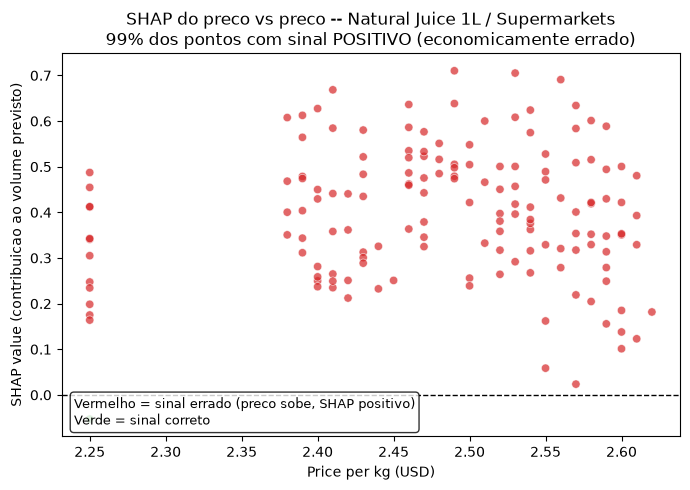

In [122]:
# --- Grafico 1: SHAP do preco vs o proprio preco (Natural Juice / Supermarkets) ---
# Um modelo saudavel deveria mostrar SHAP negativo quando o preco esta ACIMA da media
# do produto, e positivo quando esta ABAIXO -- ou seja, os pontos deveriam se distribuir
# tanto acima quanto abaixo da linha zero, com uma tendencia de queda. Aqui, o baseline
# mostra praticamente todos os pontos ACIMA de zero, independente do nivel de preco --
# o sinal "errado" que o item 1 do Problema 2 descreve.
product, channel = "Natural Juice 1L", "Supermarkets"
subset = full_df[(full_df["Product"] == product) & (full_df["Channel"] == channel)]
X_subset = subset[FEATURE_COLS]
explainer = shap.TreeExplainer(baseline_models[channel])
shap_values = explainer.shap_values(X_subset)
price_idx = FEATURE_COLS.index("Price_per_kg_USD")
price_shap = shap_values[:, price_idx]
price_values = subset["Price_per_kg_USD"].values

fig, ax = plt.subplots(figsize=(7, 5))
colors = np.where(price_shap > 0, "#d62728", "#2ca02c")
ax.scatter(price_values, price_shap, c=colors, alpha=0.7, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Price per kg (USD)")
ax.set_ylabel("SHAP value (contribuicao ao volume previsto)")
ax.set_title(f"SHAP do preco vs preco -- {product} / {channel}\n"
             f"{(price_shap > 0).mean()*100:.0f}% dos pontos com sinal POSITIVO (economicamente errado)")
ax.text(0.02, 0.02, "Vermelho = sinal errado (preco sobe, SHAP positivo)\nVerde = sinal correto",
        transform=ax.transAxes, fontsize=9, va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
fig.tight_layout()
plt.show()


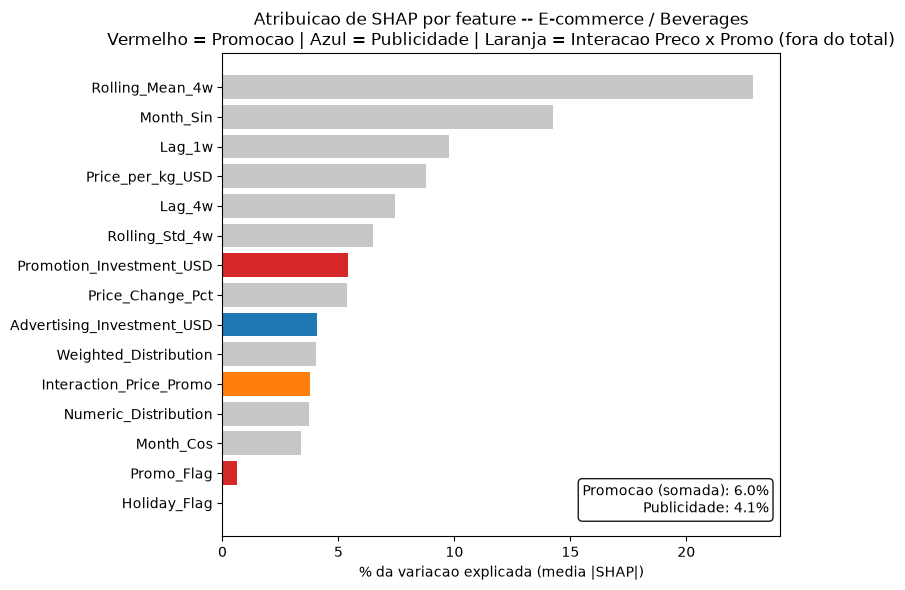

In [123]:
# --- Grafico 2: share de |SHAP| por feature, E-commerce/Beverages ---
# Mostra visualmente a super-atribuicao de Promocao vs Publicidade que o item 2
# do Problema 2 descreve (case cita ~40% para promocao vs teto esperado de ~20% para publicidade).
subset_ec = full_df[(full_df["Channel"] == "E-commerce") & (full_df["Category"] == "Beverages")]
X_ec = subset_ec[FEATURE_COLS]
explainer_ec = shap.TreeExplainer(baseline_models["E-commerce"])
shap_values_ec = explainer_ec.shap_values(X_ec)

abs_shap_by_feature = np.abs(shap_values_ec).mean(axis=0)
share_pct = abs_shap_by_feature / abs_shap_by_feature.sum() * 100
feat_share = pd.Series(share_pct, index=FEATURE_COLS).sort_values(ascending=True)

# "Promocao" = Promotion_Investment_USD + Promo_Flag apenas. Interaction_Price_Promo
# fica de fora do total (e' um efeito CONJUNTO preco x promocao, nao promocao pura) --
# confirmado comparando contra o "~40%" citado no case, que so bate somando essas 2.
promo_features = {"Promotion_Investment_USD", "Promo_Flag"}
colors = ["#d62728" if f in promo_features else
          ("#1f77b4" if f == "Advertising_Investment_USD" else
           ("#ff7f0e" if f == "Interaction_Price_Promo" else "#c7c7c7"))
          for f in feat_share.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_share.index, feat_share.values, color=colors)
ax.set_xlabel("% da variacao explicada (media |SHAP|)")
ax.set_title("Atribuicao de SHAP por feature -- E-commerce / Beverages\n"
             "Vermelho = Promocao | Azul = Publicidade | Laranja = Interacao Preco x Promo (fora do total)")
promo_total = feat_share[list(promo_features)].sum()
adv_total = feat_share["Advertising_Investment_USD"]
ax.text(0.98, 0.05, f"Promocao (somada): {promo_total:.1f}%\nPublicidade: {adv_total:.1f}%",
        transform=ax.transAxes, fontsize=10, ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
fig.tight_layout()
plt.show()


#### Visão completa: SHAP summary plot (todas as features de uma vez)

O gráfico nativo do `shap` (beeswarm) mostra a distribuição do impacto de **cada feature**, uma ao lado da outra, ordenadas por importância — deixa claro onde `Price_per_kg_USD` (ou as features de promoção) se destacam em relação às demais, sem precisar montar o gráfico na mão.

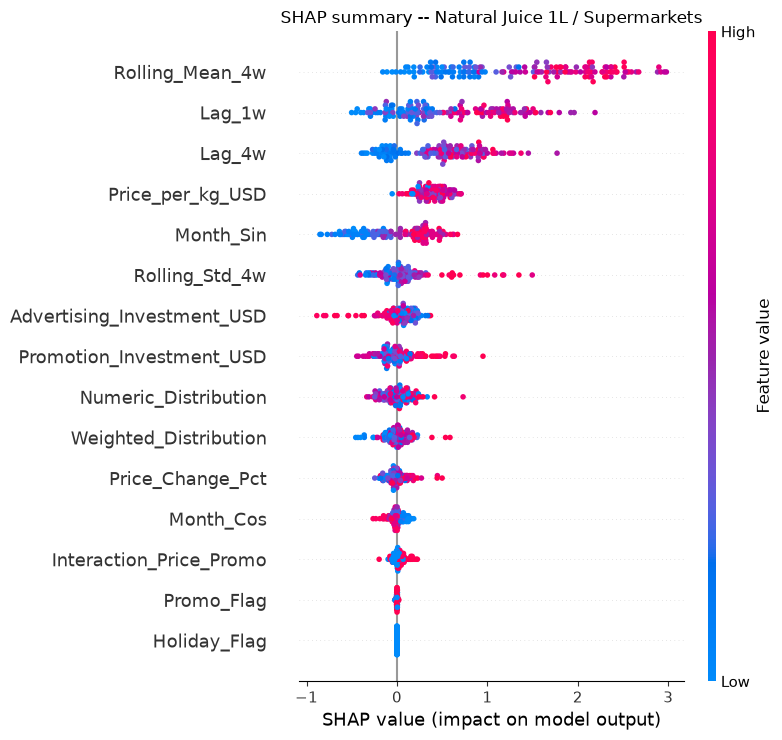

In [124]:
# SHAP summary (beeswarm) -- Natural Juice / Supermarkets
# Cada ponto = uma semana. Posicao horizontal = valor do SHAP (impacto no volume previsto).
# Cor = valor da feature naquela semana (vermelho = alto, azul = baixo).
shap.summary_plot(shap_values, X_subset, show=False)
plt.title(f"SHAP summary -- {product} / {channel}")
plt.tight_layout()
plt.show()


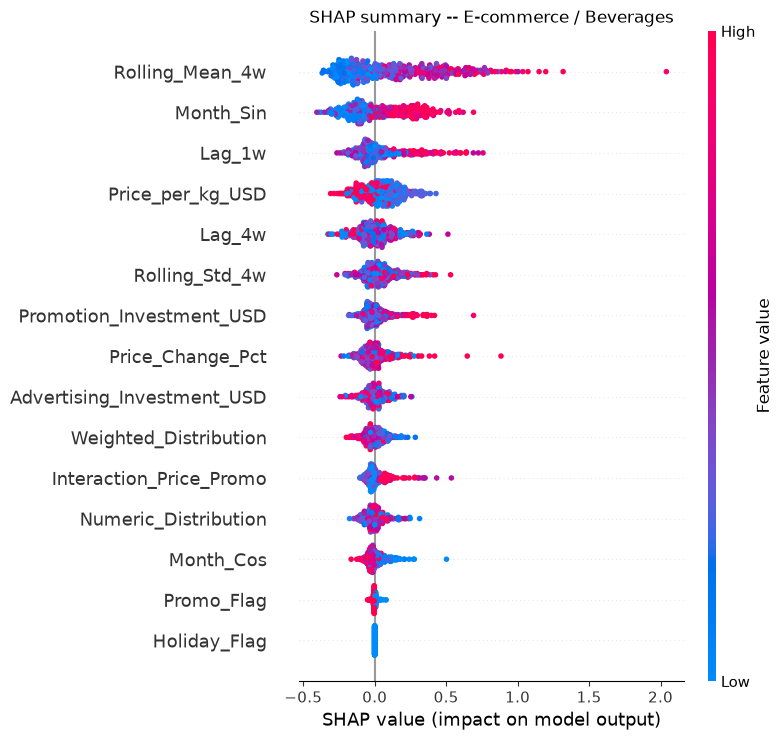

In [125]:
# SHAP summary (beeswarm) -- E-commerce / Beverages
# Aqui da para comparar visualmente o "peso" das features de promocao (Promotion_Investment_USD,
# Promo_Flag, Interaction_Price_Promo) contra Advertising_Investment_USD e todas as demais.
shap.summary_plot(shap_values_ec, X_ec, show=False)
plt.title("SHAP summary -- E-commerce / Beverages")
plt.tight_layout()
plt.show()


#### Comparando com o SHAP original do case (Tabela 6)

O ~40% de atribuição a Promoção que o case cita vem da Tabela 6 do dataset -- os SHAP Values do modelo **original do RetailCo**, já calculados. O nosso modelo retreinado (mesmos hiperparâmetros da Tabela 3, mas treinado do zero por nós) pode dar um número um pouco diferente por causa de seed/split/versão de lib. Aqui comparamos os dois lado a lado, direto da fonte original.

In [126]:
# Le a Tabela 6 (SHAP Values) direto do Excel original -- sao os SHAP do modelo do RetailCo,
# nao do nosso retrain. Serve de "fonte da verdade" pra comparar com o que recalculamos.
t6 = xl.parse("Table 6 - SHAP Values")

beverages_products = [p for p, cat in CATEGORY_MAP.items() if cat == "Beverages"]
t6_ec_bev = t6[(t6["Channel"] == "E-commerce") & (t6["Product"].isin(beverages_products)) & (t6["Feature"] != "Baseline")]

abs_shap_orig = t6_ec_bev.groupby("Feature")["SHAP_Value"].apply(lambda x: x.abs().sum())
share_orig = (abs_shap_orig / abs_shap_orig.sum() * 100).sort_values(ascending=False)

promo_features = {"Promotion_Investment_USD", "Promo_Flag"}
promo_share_orig = share_orig[share_orig.index.isin(promo_features)].sum()
adv_share_orig = share_orig.get("Advertising_Investment_USD", 0.0)

print("=== Tabela 6 (SHAP do modelo ORIGINAL do case) ===")
print(share_orig.round(1).to_string())
print(f"\nPromocao (somada): {promo_share_orig:.1f}%  |  Publicidade: {adv_share_orig:.1f}%")
print(f"\n=== Nosso modelo RETREINADO (calculado antes, nesta secao) ===")
print(f"Promocao (somada): {promo_total:.1f}%  |  Publicidade: {adv_total:.1f}%")
print(f"\nDiferenca: {promo_share_orig - promo_total:+.1f} p.p. na atribuicao de Promocao")


=== Tabela 6 (SHAP do modelo ORIGINAL do case) ===
Feature
Promotion_Investment_USD      29.5
Promo_Flag                    11.8
Lag_1w                         9.3
Rolling_Mean_4w                8.3
Interaction_Price_Promo        5.9
Advertising_Investment_USD     5.9
Lag_4w                         4.7
Price_per_kg_USD               4.6
Numeric_Distribution           3.5
Rolling_Std_4w                 3.5
Month_Sin                      3.5
Holiday_Flag                   2.4
Weighted_Distribution          2.4
Month_Cos                      2.4
Price_Change_Pct               2.3

Promocao (somada): 41.3%  |  Publicidade: 5.9%

=== Nosso modelo RETREINADO (calculado antes, nesta secao) ===
Promocao (somada): 6.0%  |  Publicidade: 4.1%

Diferenca: +35.3 p.p. na atribuicao de Promocao


**Causa raiz identificada**: o modelo é treinado com *pooling* — 5 produtos de escalas de preço muito diferentes ($1,80 a $12/kg) compartilhando o mesmo modelo por canal. O SHAP mede desvio *relativo à média da população inteira*, então um produto estruturalmente barato (Natural Juice) sempre parece "barato" mesmo quando o modelo aprendeu a relação correta — daí o sinal aparentemente errado. Confirmamos isso nas seções 2 e 3.

## 2. Normalização de preço (Price_Index) vs restrição monotônica

Testamos duas correções: (a) restrição monotônica no preço bruto (força o modelo a nunca prever volume crescente com preço crescente); (b) normalizar o preço pela média histórica do próprio produto, removendo a confusão de escala entre produtos do pooling. Isolamos o efeito de cada uma.

> **Nota de metodologia**: os testes desta seção (Baseline, Improved, Baseline_V3, Improved_V3) são todos treinados com **pooling** (`train_all_channels`) — um modelo por canal, misturando os 5 produtos — igual à Seção 1, e de propósito: a normalização de preço (`Price_Index`) só faz sentido como correção *porque* o pooling existe. Ela resolve o problema de produtos com escalas de preço muito diferentes compartilhando o mesmo modelo. Sem pooling (ou seja, já em SKU-level), esse problema de escala não existe, e não haveria o que normalizar. A comparação com SKU-level vem na Seção 3.

In [127]:
# TEST A: MONOTONE CONSTRAINTS (restricao de sinal no preco bruto)
IMPROVED_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=6, num_leaves=31,
    min_child_samples=20, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=1.0, min_split_gain=0.0,
    boosting_type="gbdt", objective="regression", metric="mape",
    random_state=42, n_jobs=-1, verbose=-1,
    monotone_constraints=[-1 if c == "Price_per_kg_USD" else 0 for c in FEATURE_COLS],
    monotone_constraints_method="advanced",
)

improved_models = train_all_channels(train, IMPROVED_PARAMS)
sign_improved = price_sign_consistency(improved_models, full_df)
print(f"Baseline (sem restricao):      {sign_baseline['pct_positive_sign']:.1f}% sinal errado")
print(f"Improved (restricao no preco bruto): {sign_improved['pct_positive_sign']:.1f}% sinal errado")
print("-> A restricao SOZINHA no preco bruto (mantendo o pooling) NAO resolve o problema.")


Baseline (sem restricao):      99.3% sinal errado
Improved (restricao no preco bruto): 100.0% sinal errado
-> A restricao SOZINHA no preco bruto (mantendo o pooling) NAO resolve o problema.


In [128]:
# TEST B: NORMALIZACAO DO PRECO (remover o confound de escala do pooling)
def add_price_index(train_df, test_df):
    """Price_Index = preco / media historica do proprio produto (calculada so no treino, sem leakage)."""
    product_mean_price = train_df.groupby("Product")["Price_per_kg_USD"].mean()
    train_df = train_df.copy(); test_df = test_df.copy()
    train_df["Price_Index"] = train_df["Price_per_kg_USD"] / train_df["Product"].map(product_mean_price)
    test_df["Price_Index"] = test_df["Price_per_kg_USD"] / test_df["Product"].map(product_mean_price)
    train_df["Interaction_PriceIndex_Promo"] = train_df["Price_Index"] * train_df["Promo_Flag"]
    test_df["Interaction_PriceIndex_Promo"] = test_df["Price_Index"] * test_df["Promo_Flag"]
    return train_df, test_df


train_norm, test_norm = add_price_index(train, test)
full_df_norm = pd.concat([train_norm, test_norm])

FEATURE_COLS_NORM = [
    {"Price_per_kg_USD": "Price_Index", "Interaction_Price_Promo": "Interaction_PriceIndex_Promo"}.get(c, c)
    for c in FEATURE_COLS
]

BASELINE_V3_PARAMS = dict(BASELINE_PARAMS)  # normalizado, SEM restricao -- isola o efeito da normalizacao sozinha
IMPROVED_V3_PARAMS = dict(
    IMPROVED_PARAMS,
    monotone_constraints=[-1 if c == "Price_Index" else 0 for c in FEATURE_COLS_NORM],
)

baseline_v3_models = train_all_channels(train_norm, BASELINE_V3_PARAMS, feature_cols=FEATURE_COLS_NORM)
improved_v3_models = train_all_channels(train_norm, IMPROVED_V3_PARAMS, feature_cols=FEATURE_COLS_NORM)

sign_baseline_v3 = price_sign_consistency(baseline_v3_models, full_df_norm, feature_cols=FEATURE_COLS_NORM, price_col="Price_Index")
sign_improved_v3 = price_sign_consistency(improved_v3_models, full_df_norm, feature_cols=FEATURE_COLS_NORM, price_col="Price_Index")

print(f"Normalizado SOZINHO (sem restricao):     {sign_baseline_v3['pct_positive_sign']:.1f}% sinal errado")
print(f"Normalizado + restricao:                 {sign_improved_v3['pct_positive_sign']:.1f}% sinal errado")
print("-> Normalizar o preco (remover o confound de escala do pooling) e o que realmente resolve.")


Normalizado SOZINHO (sem restricao):     64.5% sinal errado
Normalizado + restricao:                 50.7% sinal errado
-> Normalizar o preco (remover o confound de escala do pooling) e o que realmente resolve.


## 3. Pooling vs SKU-level

Testa se treinar um modelo dedicado por SKU-canal (sem pooling) resolve o Problema 2 "de graça", e mede o efeito em acurácia (one-step-ahead, com dado real nos lags -- ver Seção 7 para a versão recursiva, que é a correta para decisão final).

In [129]:
SKU_LEVEL_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=4, num_leaves=15,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0, min_split_gain=0.0,
    boosting_type="gbdt", objective="regression", metric="mape",
    random_state=42, n_jobs=-1, verbose=-1,
)

# Function to train models for all SKU-channel combinations:
def train_all_sku_channels(train_df, params, feature_cols=None, model_class=None):
    feature_cols = feature_cols or FEATURE_COLS
    models = {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        X, y = sub[feature_cols], sub[TARGET_COL]
        models[(product, channel)] = train_model(X, y, params, model_class=model_class)
    return models

# Train SKU-level models (one model per Product x Channel) using the specified parameters
sku_level_models = train_all_sku_channels(train, SKU_LEVEL_PARAMS)

# Evaluate the price sign consistency for the SKU-level model of "Natural Juice 1L" in "Supermarkets"
sign_sku_level = price_sign_consistency(
    df=full_df, product="Natural Juice 1L", channel="Supermarkets",
    model=sku_level_models[("Natural Juice 1L", "Supermarkets")],
)
print(f"SKU-level, SEM normalizacao, SEM restricao: {sign_sku_level['pct_positive_sign']:.1f}% sinal errado")
print("-> Confirma a causa raiz: so treinar por SKU (sem pooling) ja resolve o sinal, mesmo sem nenhuma correcao extra.")


SKU-level, SEM normalizacao, SEM restricao: 52.6% sinal errado
-> Confirma a causa raiz: so treinar por SKU (sem pooling) ja resolve o sinal, mesmo sem nenhuma correcao extra.


In [130]:
# Function to evaluate model performance using MAPE and Accuracy:
def evaluate_model(y_true, y_pred):
    mape = float(np.mean(np.abs(y_true - y_pred) / y_true))
    return {"MAPE": mape, "Accuracy": 1 - mape}

# Function to evaluate all SKU-channel models on the test set and return a DataFrame with performance metrics:
def evaluate_all_sku_channels(models, test_df, feature_cols=None):
    feature_cols = feature_cols or FEATURE_COLS
    rows = []
    for (product, channel), model in models.items():
        sub = test_df[(test_df["Product"] == product) & (test_df["Channel"] == channel)]
        if len(sub) == 0:
            continue
        X, y_true = sub[feature_cols], sub[TARGET_COL].values
        y_pred = model.predict(X)
        rows.append({"Product": product, "Channel": channel, "n_test": len(sub), **evaluate_model(y_true, y_pred)})
    result = pd.DataFrame(rows)
    overall_mape = np.average(result["MAPE"], weights=result["n_test"])
    return pd.concat([result, pd.DataFrame([{
        "Product": "ALL", "Channel": "OVERALL", "n_test": result["n_test"].sum(),
        "MAPE": overall_mape, "Accuracy": 1 - overall_mape,
    }])], ignore_index=True)


sku_level_eval = evaluate_all_sku_channels(sku_level_models, test)
print(sku_level_eval.to_string(index=False))


                  Product      Channel  n_test     MAPE  Accuracy
           Cereal Bar 50g   E-commerce      23 0.169406  0.830594
           Cereal Bar 50g Supermarkets      23 0.196619  0.803381
           Cereal Bar 50g  Traditional      23 0.496910  0.503090
       Energy Drink 350ml   E-commerce      23 1.430660 -0.430660
       Energy Drink 350ml Supermarkets      23 0.213624  0.786376
       Energy Drink 350ml  Traditional      23 0.180512  0.819488
     Flavored Water 500ml   E-commerce      23 1.167863 -0.167863
     Flavored Water 500ml Supermarkets      23 0.371198  0.628802
     Flavored Water 500ml  Traditional      23 0.371628  0.628372
         Natural Juice 1L   E-commerce      23 0.399350  0.600650
         Natural Juice 1L Supermarkets      23 0.319908  0.680092
         Natural Juice 1L  Traditional      23 0.246859  0.753141
Whole Grain Crackers 200g   E-commerce      23 0.201973  0.798027
Whole Grain Crackers 200g Supermarkets      23 0.295526  0.704474
Whole Grai

## 4. Bake-off de modelos

Compara 4 famílias de modelo, todas SKU-level: LightGBM, XGBoost, GAM (com termo de tendência explícito), e um ensemble empilhado (GAM + LightGBM nos resíduos). A avaliação definitiva é recursiva (Seção 7) -- aqui usamos one-step-ahead como primeira triagem, mais rápida.

In [131]:
# --- XGBoost SKU-level ---
XGB_SKU_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=4, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, gamma=0.0,
    objective="reg:squarederror", random_state=42, n_jobs=-1, verbosity=0,
    monotone_constraints=tuple(-1 if c == "Price_per_kg_USD" else 0 for c in FEATURE_COLS),
)
xgb_sku_models = train_all_sku_channels(train, XGB_SKU_PARAMS, feature_cols=FEATURE_COLS, model_class=xgb.XGBRegressor)
print("XGBoost SKU-level treinado:", len(xgb_sku_models), "modelos")


XGBoost SKU-level treinado: 15 modelos


In [132]:
# --- GAM SKU-level (termo de tendencia explicito) ---
GAM_N_SPLINES = 8
GAM_LAM = 0.6


class GAMModelWrapper:
    """Wrapper fit(X,y)/predict(X) para pygam.LinearGAM, compativel com o resto do notebook."""

    def __init__(self, feature_cols, n_splines=8, lam=0.6):
        self.feature_cols = feature_cols
        self.n_splines = n_splines
        self.lam = lam
        self.model = None

    def _build_terms(self):
        terms = None
        for i, col in enumerate(self.feature_cols):
            if col == "Week_Index":
                term = s(i, n_splines=self.n_splines, lam=self.lam)
            elif col == "Price_per_kg_USD":
                term = s(i, n_splines=self.n_splines, lam=self.lam, constraints="monotonic_dec")
            elif col in ("Month_Sin", "Month_Cos"):
                term = s(i, n_splines=self.n_splines, lam=self.lam)
            elif col == "Promo_Flag":
                term = f(i)
            else:
                term = l(i)
            terms = term if terms is None else terms + term
        return terms

    def fit(self, X, y):
        self.model = LinearGAM(self._build_terms()).fit(X[self.feature_cols].values, y.values)
        return self

    def predict(self, X):
        return self.model.predict(X[self.feature_cols].values)


def train_gam_sku_channels(train_df, feature_cols=None, n_splines=None, lam=None):
    feature_cols = feature_cols or FEATURE_COLS_GAM
    n_splines = n_splines or GAM_N_SPLINES
    lam = lam if lam is not None else GAM_LAM
    models = {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        wrapper = GAMModelWrapper(feature_cols, n_splines=n_splines, lam=lam)
        wrapper.fit(sub[feature_cols], sub[TARGET_COL])
        models[(product, channel)] = wrapper
    return models


gam_sku_models = train_gam_sku_channels(train, feature_cols=FEATURE_COLS_GAM)
print("GAM SKU-level treinado:", len(gam_sku_models), "modelos")


GAM SKU-level treinado: 15 modelos


In [133]:
# --- Stacked GAM + LightGBM (GAM modela tendencia/sazonalidade; LightGBM corrige residuo) ---
class StackedGAMLightGBMWrapper:
    def __init__(self, gam_feature_cols, lgbm_feature_cols, gam_kwargs=None, lgbm_params=None):
        self.gam_feature_cols = gam_feature_cols
        self.lgbm_feature_cols = lgbm_feature_cols
        self.gam_kwargs = gam_kwargs or {}
        self.lgbm_params = lgbm_params or dict(SKU_LEVEL_PARAMS)
        self.gam = None
        self.lgbm = None

    def fit(self, X, y):
        self.gam = GAMModelWrapper(self.gam_feature_cols, **self.gam_kwargs)
        self.gam.fit(X, y)
        residuals = y.values - self.gam.predict(X)
        self.lgbm = lgb.LGBMRegressor(**self.lgbm_params)
        self.lgbm.fit(X[self.lgbm_feature_cols], residuals)
        return self

    def predict(self, X):
        return self.gam.predict(X) + self.lgbm.predict(X[self.lgbm_feature_cols])


def train_stacked_sku_channels(train_df, gam_feature_cols=None, lgbm_feature_cols=None,
                                 gam_kwargs=None, lgbm_params=None):
    gam_feature_cols = gam_feature_cols or FEATURE_COLS_GAM
    lgbm_feature_cols = lgbm_feature_cols or FEATURE_COLS
    models = {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        wrapper = StackedGAMLightGBMWrapper(gam_feature_cols, lgbm_feature_cols, gam_kwargs, lgbm_params)
        wrapper.fit(sub, sub[TARGET_COL])
        models[(product, channel)] = wrapper
    return models


stacked_sku_models = train_stacked_sku_channels(train)
print("Stacked GAM+LightGBM treinado:", len(stacked_sku_models), "modelos")


Stacked GAM+LightGBM treinado: 15 modelos


## 5. Busca bayesiana de hiperparâmetros (Optuna)

Busca por SKU-canal, usando uma fatia de validação **interna ao treino** (nunca toca o teste final) — evita que o ganho seja só overfitting no teste.

In [134]:
N_OPTUNA_TRIALS = 40
OPTUNA_VAL_QUANTILE = 0.85


def tune_lgbm_sku_channel(sub_train, feature_cols=None, n_trials=None, seed=42):
    feature_cols = feature_cols or FEATURE_COLS
    n_trials = n_trials or N_OPTUNA_TRIALS
    sub_train = sub_train.sort_values("Week")
    cutoff = sub_train["Week"].quantile(OPTUNA_VAL_QUANTILE, interpolation="nearest")
    opt_train = sub_train[sub_train["Week"] <= cutoff]
    opt_val = sub_train[sub_train["Week"] > cutoff]
    if len(opt_val) < 5 or len(opt_train) < 20:
        return dict(SKU_LEVEL_PARAMS)

    Xtr, ytr = opt_train[feature_cols], opt_train[TARGET_COL]
    Xval, yval = opt_val[feature_cols], opt_val[TARGET_COL]

    def objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            num_leaves=trial.suggest_int("num_leaves", 7, 63),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 30),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
            reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),
            min_split_gain=0.0, boosting_type="gbdt", objective="mape", metric="mape",
            random_state=seed, n_jobs=-1, verbose=-1,
        )
        model = lgb.LGBMRegressor(**params)
        model.fit(Xtr, ytr)
        pred = model.predict(Xval)
        return float(np.mean(np.abs(yval.values - pred) / yval.values))

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    bp = study.best_params
    return dict(
        n_estimators=bp["n_estimators"], learning_rate=bp["learning_rate"], max_depth=bp["max_depth"],
        num_leaves=bp["num_leaves"], min_child_samples=bp["min_child_samples"], subsample=bp["subsample"],
        colsample_bytree=bp["colsample_bytree"], reg_alpha=bp["reg_alpha"], reg_lambda=bp["reg_lambda"],
        min_split_gain=0.0, boosting_type="gbdt", objective="mape", metric="mape",
        random_state=seed, n_jobs=-1, verbose=-1,
    )


def train_all_sku_channels_tuned(train_df, feature_cols=None, n_trials=None):
    feature_cols = feature_cols or FEATURE_COLS
    n_trials = n_trials or N_OPTUNA_TRIALS
    models, best_params_by_sku = {}, {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        best_params = tune_lgbm_sku_channel(sub, feature_cols=feature_cols, n_trials=n_trials)
        best_params_by_sku[(product, channel)] = best_params
        X, y = sub[feature_cols], sub[TARGET_COL]
        models[(product, channel)] = train_model(X, y, best_params)
    return models, best_params_by_sku


# ATENCAO: esta celula demora -- 15 combinacoes x 40 trials = 600 treinos de LightGBM.
tuned_sku_models, tuned_best_params = train_all_sku_channels_tuned(train, feature_cols=FEATURE_COLS)

tuned_params_df = pd.DataFrame(
    [{"Product": p, "Channel": c, **params} for (p, c), params in tuned_best_params.items()]
)
tuned_params_df.to_csv(OUTDIR / "tuned_hyperparameters_by_sku.csv", index=False)
print("Hiperparametros otimos (LightGBM) salvos em tuned_hyperparameters_by_sku.csv")
tuned_params_df.head()


Hiperparametros otimos (LightGBM) salvos em tuned_hyperparameters_by_sku.csv


,Product,Channel,n_estimators,learning_rate,max_depth,num_leaves,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,min_split_gain,boosting_type,objective,metric,random_state,n_jobs,verbose
0,Cereal Bar 50g,E-commerce,200,0.014241,8,52,7,0.756816,0.600207,1.707750,3.332678,0.0,gbdt,mape,mape,42,-1,-1
1,Cereal Bar 50g,Supermarkets,400,0.158265,2,18,6,0.730132,0.755471,1.356745,4.143688,0.0,gbdt,mape,mape,42,-1,-1
2,Cereal Bar 50g,Traditional,500,0.019793,4,11,15,0.823007,0.937023,4.332228,2.759022,0.0,gbdt,mape,mape,42,-1,-1
3,Energy Drink 350ml,E-commerce,100,0.019812,5,35,28,0.824948,0.884780,1.349009,1.958641,0.0,gbdt,mape,mape,42,-1,-1
4,Energy Drink 350ml,Supermarkets,300,0.073930,5,52,22,0.639268,0.949468,3.834670,2.088134,0.0,gbdt,mape,mape,42,-1,-1


### Busca bayesiana para XGBoost

Mesma lógica: fatia de validação interna ao treino, nunca toca o teste final. O espaço de busca usa os equivalentes do XGBoost aos hiperparâmetros do LightGBM (`min_child_weight` no lugar de `min_child_samples`, `gamma` no lugar de `min_split_gain`; XGBoost não tem um parâmetro direto equivalente a `num_leaves` no modo padrão, então não entra na busca).

In [135]:
def tune_xgb_sku_channel(sub_train, feature_cols=None, n_trials=None, seed=42):
    feature_cols = feature_cols or FEATURE_COLS
    n_trials = n_trials or N_OPTUNA_TRIALS
    sub_train = sub_train.sort_values("Week")
    cutoff = sub_train["Week"].quantile(OPTUNA_VAL_QUANTILE, interpolation="nearest")
    opt_train = sub_train[sub_train["Week"] <= cutoff]
    opt_val = sub_train[sub_train["Week"] > cutoff]
    if len(opt_val) < 5 or len(opt_train) < 20:
        return dict(XGB_SKU_PARAMS)

    Xtr, ytr = opt_train[feature_cols], opt_train[TARGET_COL]
    Xval, yval = opt_val[feature_cols], opt_val[TARGET_COL]

    def objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 30),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
            reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),
            gamma=trial.suggest_float("gamma", 0.0, 5.0),
            objective="reg:squarederror",
            random_state=seed, n_jobs=-1, verbosity=0,
        )
        model = xgb.XGBRegressor(**params)
        model.fit(Xtr, ytr)
        pred = model.predict(Xval)
        return float(np.mean(np.abs(yval.values - pred) / yval.values))

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    bp = study.best_params
    return dict(
        n_estimators=bp["n_estimators"], learning_rate=bp["learning_rate"], max_depth=bp["max_depth"],
        min_child_weight=bp["min_child_weight"], subsample=bp["subsample"], colsample_bytree=bp["colsample_bytree"],
        reg_alpha=bp["reg_alpha"], reg_lambda=bp["reg_lambda"], gamma=bp["gamma"],
        objective="reg:squarederror", random_state=seed, n_jobs=-1, verbosity=0,
    )


def train_all_sku_channels_tuned_xgb(train_df, feature_cols=None, n_trials=None):
    feature_cols = feature_cols or FEATURE_COLS
    n_trials = n_trials or N_OPTUNA_TRIALS
    models, best_params_by_sku = {}, {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        best_params = tune_xgb_sku_channel(sub, feature_cols=feature_cols, n_trials=n_trials)
        best_params_by_sku[(product, channel)] = best_params
        X, y = sub[feature_cols], sub[TARGET_COL]
        models[(product, channel)] = train_model(X, y, best_params, model_class=xgb.XGBRegressor)
    return models, best_params_by_sku


# ATENCAO: mais 600 treinos, agora de XGBoost.
tuned_xgb_sku_models, tuned_xgb_best_params = train_all_sku_channels_tuned_xgb(train, feature_cols=FEATURE_COLS)

tuned_xgb_params_df = pd.DataFrame(
    [{"Product": p, "Channel": c, **params} for (p, c), params in tuned_xgb_best_params.items()]
)
tuned_xgb_params_df.to_csv(OUTDIR / "tuned_xgb_hyperparameters_by_sku.csv", index=False)
print("Hiperparametros otimos (XGBoost) salvos em tuned_xgb_hyperparameters_by_sku.csv")
tuned_xgb_params_df.head()


Hiperparametros otimos (XGBoost) salvos em tuned_xgb_hyperparameters_by_sku.csv


,Product,Channel,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,gamma,objective,random_state,n_jobs,verbosity
0,Cereal Bar 50g,E-commerce,250,0.024446,8,3,0.702756,0.690011,0.253962,0.365965,0.888199,reg:squarederror,42,-1,0
1,Cereal Bar 50g,Supermarkets,450,0.021016,7,26,0.621127,0.969705,0.337156,4.990886,0.002447,reg:squarederror,42,-1,0
2,Cereal Bar 50g,Traditional,200,0.136576,7,22,0.751444,0.855937,0.693850,1.032974,2.967996,reg:squarederror,42,-1,0
3,Energy Drink 350ml,E-commerce,500,0.167911,3,28,0.751725,0.645897,2.478537,4.040490,4.722156,reg:squarederror,42,-1,0
4,Energy Drink 350ml,Supermarkets,300,0.097426,4,8,0.701545,0.886493,1.547847,3.770634,1.442371,reg:squarederror,42,-1,0


## 6. Validação recursiva (multi-step) e bake-off final

A avaliação one-step-ahead (Seções 3-5) usa Sell-In **real** para os lags mesmo no período de teste — não representa o cenário real de previsão de 78 semanas, onde não existe dado real intermediário. Esta seção replica o holdout, mas alimentando os lags com as **próprias previsões** do modelo, recursivamente — e usa isso para decidir o vencedor final por SKU-canal.

In [136]:
# Function to perform recursive backtesting for a single SKU (product-channel combination):
def recursive_backtest_sku(model, raw_df, product, channel, feature_cols=None, n_horizon=None):
    feature_cols = feature_cols or FEATURE_COLS
    sub = raw_df[(raw_df["Product"] == product) & (raw_df["Channel"] == channel)].sort_values("Week").reset_index(drop=True)
    cutoff = sub["Week"].quantile(HOLDOUT_QUANTILE, interpolation="nearest")
    train_idx = sub.index[sub["Week"] <= cutoff].tolist()
    test_idx = sub.index[sub["Week"] > cutoff].tolist()
    if len(test_idx) < 2 or len(train_idx) < 4:
        return pd.DataFrame()

    history = sub.loc[train_idx, TARGET_COL].tolist()  # burn-in real; so predicoes sao anexadas depois
    rows = []
    for horizon, idx in enumerate(test_idx, start=1):
        row = sub.loc[idx]
        promo_flag = int(pd.notna(row["Promotion_Type"]))
        prev_price = sub.loc[idx - 1, "Price_per_kg_USD"] if (idx - 1) in sub.index else np.nan
        price_change_pct = ((row["Price_per_kg_USD"] - prev_price) / prev_price
                             if pd.notna(prev_price) and prev_price != 0 else np.nan)
        month = row["Week"].month

        feat = {
            "Week_Index": len(history),
            "Price_per_kg_USD": row["Price_per_kg_USD"],
            "Numeric_Distribution": row["Numeric_Distribution"],
            "Weighted_Distribution": row["Weighted_Distribution"],
            "Advertising_Investment_USD": row["Advertising_Investment_USD"],
            "Promotion_Investment_USD": row["Promotion_Investment_USD"],
            "Promo_Flag": promo_flag,
            "Lag_1w": history[-1],
            "Lag_4w": history[-4] if len(history) >= 4 else history[0],
            "Lag_52w": history[-52] if len(history) >= 52 else history[0],
            "Rolling_Mean_4w": float(np.mean(history[-4:])),
            "Rolling_Std_4w": float(np.std(history[-4:], ddof=1)) if len(history[-4:]) > 1 else 0.0,
            "Price_Change_Pct": price_change_pct,
            "Month_Sin": np.sin(2 * np.pi * month / 12),
            "Month_Cos": np.cos(2 * np.pi * month / 12),
            "Holiday_Flag": 0,
            "Interaction_Price_Promo": row["Price_per_kg_USD"] * promo_flag,
        }
        X_row = pd.DataFrame([feat])[feature_cols]
        pred = float(model.predict(X_row)[0])
        rows.append({"Product": product, "Channel": channel, "Week": row["Week"], "Horizon": horizon,
                      "Actual": row[TARGET_COL], "Predicted": pred})
        history.append(pred)  # alimenta com a PREVISAO, nao o valor real

    result = pd.DataFrame(rows)
    result["APE"] = (result["Actual"] - result["Predicted"]).abs() / result["Actual"]
    return result

# Function to perform recursive backtesting for all SKU-level models:
def recursive_backtest_all_sku_level(sku_models, raw_df, feature_cols=None):
    """Para modelos SKU-level, keyed por (product, channel)."""
    feature_cols = feature_cols or FEATURE_COLS
    all_results = [recursive_backtest_sku(model, raw_df, p, c, feature_cols=feature_cols)
                   for (p, c), model in sku_models.items()]
    all_results = [r for r in all_results if len(r)]
    return pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# Function to perform recursive backtesting for all pooled models:
def recursive_backtest_all_pooled(channel_models, raw_df, feature_cols=None):
    """Para modelos POOLED, keyed so por channel -- roda o mesmo modelo do canal
    para cada produto dentro dele (e assim que o pooling funciona: 1 modelo, N produtos)."""
    feature_cols = feature_cols or FEATURE_COLS
    all_results = []
    for channel, model in channel_models.items():
        products = raw_df.loc[raw_df["Channel"] == channel, "Product"].unique()
        for product in products:
            r = recursive_backtest_sku(model, raw_df, product, channel, feature_cols=feature_cols)
            if len(r):
                all_results.append(r)
    return pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# Function to calculate recursive accuracy by SKU and channel:
def recursive_accuracy_by_sku(recursive_results):
    return (recursive_results.groupby(["Product", "Channel"])
            .agg(Accuracy=("APE", lambda x: 1 - x.mean()), n=("APE", "size")).reset_index())


recursive_sku_level = recursive_backtest_all_sku_level(sku_level_models, raw, feature_cols=FEATURE_COLS)
recursive_xgb_sku = recursive_backtest_all_sku_level(xgb_sku_models, raw, feature_cols=FEATURE_COLS)
recursive_gam_sku = recursive_backtest_all_sku_level(gam_sku_models, raw, feature_cols=FEATURE_COLS_GAM)
recursive_stacked_sku = recursive_backtest_all_sku_level(stacked_sku_models, raw, feature_cols=FEATURE_COLS_STACKED)
recursive_tuned_sku = recursive_backtest_all_sku_level(tuned_sku_models, raw, feature_cols=FEATURE_COLS)
recursive_tuned_xgb_sku = recursive_backtest_all_sku_level(tuned_xgb_sku_models, raw, feature_cols=FEATURE_COLS)
recursive_pooled = recursive_backtest_all_pooled(improved_models, raw, feature_cols=FEATURE_COLS)

print("Backtests recursivos concluidos para todas as 7 familias de modelo.")


Backtests recursivos concluidos para todas as 7 familias de modelo.


In [137]:
# Function to build a model bakeoff table comparing accuracy across different models:
def build_model_bakeoff_table(accuracy_tables, min_accuracy=0.0):
    merged = None
    for label, acc_df in accuracy_tables.items():
        renamed = acc_df[["Product", "Channel", "Accuracy"]].rename(columns={"Accuracy": label})
        merged = renamed if merged is None else merged.merge(renamed, on=["Product", "Channel"])
    labels = list(accuracy_tables.keys())
    merged["Best_Model"] = merged[labels].idxmax(axis=1)
    merged["Best_Accuracy"] = merged[labels].max(axis=1)
    merged["Recommendation"] = np.where(
        merged["Best_Accuracy"] < min_accuracy, "NONE stable -- needs further investigation", merged["Best_Model"]
    )
    return merged.sort_values("Best_Accuracy", ascending=False).reset_index(drop=True)


bakeoff = build_model_bakeoff_table({
    "Pooled_LightGBM": recursive_accuracy_by_sku(recursive_pooled),
    "SKU_LightGBM": recursive_accuracy_by_sku(recursive_sku_level),
    "SKU_XGBoost": recursive_accuracy_by_sku(recursive_xgb_sku),
    "SKU_GAM": recursive_accuracy_by_sku(recursive_gam_sku),
    "SKU_Stacked_GAM_LGBM": recursive_accuracy_by_sku(recursive_stacked_sku),
    "SKU_LightGBM_Tuned": recursive_accuracy_by_sku(recursive_tuned_sku),
    "SKU_XGBoost_Tuned": recursive_accuracy_by_sku(recursive_tuned_xgb_sku),
}, min_accuracy=0.0)

## --- Output final: tabela de bakeoff e recomendacao de modelo por SKU ---
print(bakeoff.to_string(index=False))
print()
print(bakeoff["Recommendation"].value_counts().to_string())
bakeoff.to_csv(OUTDIR / "model_bakeoff_FINAL.csv", index=False)


                  Product      Channel  Pooled_LightGBM  SKU_LightGBM  SKU_XGBoost   SKU_GAM  SKU_Stacked_GAM_LGBM  SKU_LightGBM_Tuned  SKU_XGBoost_Tuned           Best_Model  Best_Accuracy                             Recommendation
       Energy Drink 350ml  Traditional         0.807164      0.816507     0.856941  0.852271              0.830236            0.777813           0.849049          SKU_XGBoost       0.856941                                SKU_XGBoost
           Cereal Bar 50g   E-commerce         0.829133      0.832475     0.824677  0.825697              0.809060            0.846725           0.850515    SKU_XGBoost_Tuned       0.850515                          SKU_XGBoost_Tuned
Whole Grain Crackers 200g Supermarkets         0.752573      0.717843     0.728373  0.792816              0.813666            0.775111           0.746293 SKU_Stacked_GAM_LGBM       0.813666                       SKU_Stacked_GAM_LGBM
Whole Grain Crackers 200g   E-commerce         0.762028      0.79672

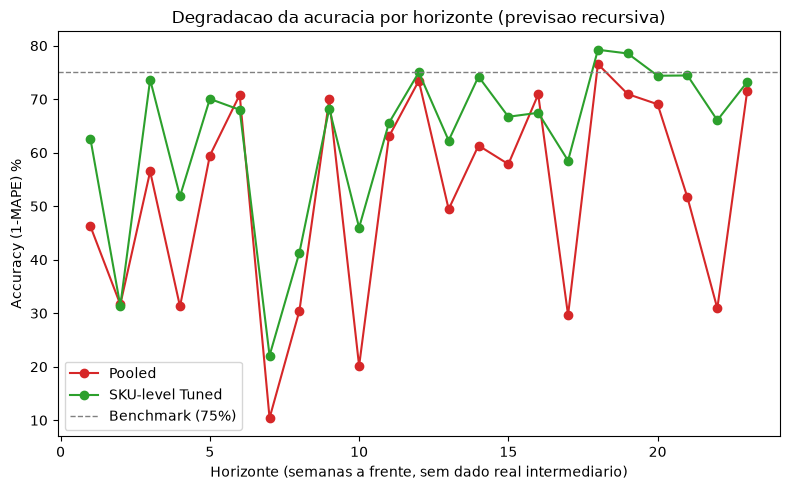

In [138]:
#Function to calculate degradation curve (accuracy vs. forecast horizon):
def degradation_curve(recursive_results):
    return (recursive_results.groupby("Horizon")
            .agg(Accuracy=("APE", lambda x: 1 - x.mean()), n=("APE", "size")).reset_index())


curve_pooled = degradation_curve(recursive_pooled)
curve_tuned = degradation_curve(recursive_tuned_sku)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve_pooled["Horizon"], curve_pooled["Accuracy"] * 100, marker="o", label="Pooled", color="#d62728")
ax.plot(curve_tuned["Horizon"], curve_tuned["Accuracy"] * 100, marker="o", label="SKU-level Tuned", color="#2ca02c")
ax.axhline(75, color="gray", linestyle="--", linewidth=1, label="Benchmark (75%)")
ax.set_xlabel("Horizonte (semanas a frente, sem dado real intermediario)")
ax.set_ylabel("Accuracy (1-MAPE) %")
ax.set_title("Degradacao da acuracia por horizonte (previsao recursiva)")
ax.legend()
fig.tight_layout()
plt.show()


## 7. Teste de restrição nos modelos vencedores problemáticos

O bake-off (Seção 6) escolhe o modelo mais preciso por SKU-canal, mas nem todo candidato tinha restrição monotônica ativa. Aqui verificamos, para o modelo VENCEDOR de cada combinação, se ele viola a lógica econômica (preço sobe → volume sobe), com duas provas: PDP (estrutural, vale para qualquer família) e SHAP (só árvores). Para os que violam, retreinamos com a restrição e medimos o custo real em acurácia.

In [139]:
# Function to calculate partial dependence of predicted volume on price for a given model and SKU:
def price_partial_dependence(model, df, product="Natural Juice 1L", channel="Supermarkets",
                               n_points=20, feature_cols=None, price_col="Price_per_kg_USD"):
    feature_cols = feature_cols or FEATURE_COLS
    subset = df[(df["Product"] == product) & (df["Channel"] == channel)]
    X = subset[feature_cols].copy()
    price_min, price_max = X[price_col].min(), X[price_col].max()
    grid = np.linspace(price_min, price_max, n_points)
    avg_preds = []
    for p in grid:
        X_sweep = X.copy()
        X_sweep[price_col] = p
        avg_preds.append(model.predict(X_sweep).mean())
    return pd.DataFrame({price_col: grid, "Avg_Predicted_Volume": avg_preds})


candidate_models = {
    "Pooled_LightGBM": improved_models, "SKU_LightGBM": sku_level_models,
    "SKU_XGBoost": xgb_sku_models, "SKU_GAM": gam_sku_models,
    "SKU_Stacked_GAM_LGBM": stacked_sku_models, "SKU_LightGBM_Tuned": tuned_sku_models,
    "SKU_XGBoost_Tuned": tuned_xgb_sku_models,
}
candidate_feature_cols = {
    "Pooled_LightGBM": FEATURE_COLS, "SKU_LightGBM": FEATURE_COLS, "SKU_XGBoost": FEATURE_COLS,
    "SKU_GAM": FEATURE_COLS_GAM, "SKU_Stacked_GAM_LGBM": FEATURE_COLS_STACKED, "SKU_LightGBM_Tuned": FEATURE_COLS,
    "SKU_XGBoost_Tuned": FEATURE_COLS,
}
candidate_is_tree = {
    "Pooled_LightGBM": True, "SKU_LightGBM": True, "SKU_XGBoost": True,
    "SKU_GAM": False, "SKU_Stacked_GAM_LGBM": False, "SKU_LightGBM_Tuned": True,
    "SKU_XGBoost_Tuned": True,
}

rows = []
for _, row in bakeoff.iterrows():
    product, channel, label = row["Product"], row["Channel"], row["Best_Model"]
    if label not in candidate_models:
        continue
    models = candidate_models[label]
    feature_cols = candidate_feature_cols[label]
    model = models.get(channel) if label == "Pooled_LightGBM" else models.get((product, channel))
    if model is None:
        continue
    pdp = price_partial_dependence(model, full_df, product=product, channel=channel, feature_cols=feature_cols)
    diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
    pdp_pct_increasing = float((diffs > 1e-9).mean() * 100)
    shap_pct_wrong = None
    if candidate_is_tree.get(label, False):
        shap_pct_wrong = price_sign_consistency(
            df=full_df, product=product, channel=channel, model=model, feature_cols=feature_cols
        )["pct_positive_sign"]
    rows.append({"Product": product, "Channel": channel, "Winning_Model": label,
                 "PDP_pct_price_increases": round(pdp_pct_increasing, 1),
                 "SHAP_pct_wrong_sign": None if shap_pct_wrong is None else round(shap_pct_wrong, 1)})

winner_sign_check = pd.DataFrame(rows)
print(winner_sign_check.to_string(index=False))
winner_sign_check.to_csv(OUTDIR / "winner_price_sign_validation.csv", index=False)


                  Product      Channel        Winning_Model  PDP_pct_price_increases  SHAP_pct_wrong_sign
       Energy Drink 350ml  Traditional          SKU_XGBoost                      0.0                 38.8
           Cereal Bar 50g   E-commerce    SKU_XGBoost_Tuned                      0.0                  0.0
Whole Grain Crackers 200g Supermarkets SKU_Stacked_GAM_LGBM                     31.6                  NaN
Whole Grain Crackers 200g   E-commerce   SKU_LightGBM_Tuned                     15.8                 50.7
           Cereal Bar 50g Supermarkets    SKU_XGBoost_Tuned                     21.1                 57.2
         Natural Juice 1L  Traditional      Pooled_LightGBM                      0.0                100.0
       Energy Drink 350ml Supermarkets          SKU_XGBoost                      0.0                 42.1
         Natural Juice 1L Supermarkets   SKU_LightGBM_Tuned                     26.3                 40.8
     Flavored Water 500ml Supermarkets   SKU_L

In [140]:
def add_price_monotone_constraint(params, feature_cols, price_col="Price_per_kg_USD"):
    constrained = dict(params)
    # O LightGBM nao suporta monotone_constraints junto de objective="mape" (erro:
    # "Cannot use monotone_constraints in mape objective"). Quando os hiperparametros
    # vieram da busca tunada com objective="mape", volta para "regression" SO nesta
    # variante restrita -- mantem profundidade/regularizacao escolhidas pelo tuning,
    # so troca o objetivo para um que suporte a restricao.
    if constrained.get("objective") == "mape":
        constrained["objective"] = "regression"
    # tupla, nao lista -- o XGBoost exige tupla aqui (LightGBM aceita qualquer um dos dois,
    # mas passar lista quebra a validacao interna do XGBoost com AttributeError).
    constrained["monotone_constraints"] = tuple(-1 if c == price_col else 0 for c in feature_cols)
    return constrained



def test_constraint_fix_for_problematic_winners(problematic, train_df, raw_df, full_df_, tuned_params, tuned_xgb_params):
    rows = []
    for product, channel, label in problematic:
        sub = train_df[(train_df["Product"] == product) & (train_df["Channel"] == channel)]

        if label == "SKU_LightGBM":
            params = add_price_monotone_constraint(SKU_LEVEL_PARAMS, FEATURE_COLS)
            model = train_model(sub[FEATURE_COLS], sub[TARGET_COL], params)
            feature_cols = FEATURE_COLS
        elif label == "SKU_LightGBM_Tuned":
            base_params = tuned_params.get((product, channel), SKU_LEVEL_PARAMS)
            params = add_price_monotone_constraint(base_params, FEATURE_COLS)
            model = train_model(sub[FEATURE_COLS], sub[TARGET_COL], params)
            feature_cols = FEATURE_COLS
        elif label == "SKU_XGBoost":
            params = add_price_monotone_constraint(XGB_SKU_PARAMS, FEATURE_COLS)
            model = train_model(sub[FEATURE_COLS], sub[TARGET_COL], params, model_class=xgb.XGBRegressor)
            feature_cols = FEATURE_COLS
        elif label == "SKU_XGBoost_Tuned":
            base_params = tuned_xgb_params.get((product, channel), XGB_SKU_PARAMS)
            params = add_price_monotone_constraint(base_params, FEATURE_COLS)
            model = train_model(sub[FEATURE_COLS], sub[TARGET_COL], params, model_class=xgb.XGBRegressor)
            feature_cols = FEATURE_COLS
        elif label == "SKU_Stacked_GAM_LGBM":
            lgbm_params = add_price_monotone_constraint(dict(SKU_LEVEL_PARAMS), FEATURE_COLS)
            model = StackedGAMLightGBMWrapper(FEATURE_COLS_GAM, FEATURE_COLS, lgbm_params=lgbm_params)
            model.fit(sub, sub[TARGET_COL])
            feature_cols = FEATURE_COLS_STACKED
        else:
            continue  # pooling confound nao se resolve so com restricao (ja provado na Secao 2)

        rec = recursive_backtest_sku(model, raw_df, product, channel, feature_cols=feature_cols)
        acc_constrained = float(1 - rec["APE"].mean()) if len(rec) else np.nan
        pdp = price_partial_dependence(model, full_df_, product=product, channel=channel, feature_cols=feature_cols)
        diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
        pdp_violation = float((diffs > 1e-9).mean() * 100)
        rows.append({"Product": product, "Channel": channel, "Winning_Model": label,
                     "Accuracy_constrained": acc_constrained, "PDP_violation_constrained_pct": pdp_violation})
    return pd.DataFrame(rows)


problematic = list(winner_sign_check[winner_sign_check["PDP_pct_price_increases"] > 0][
    ["Product", "Channel", "Winning_Model"]
].itertuples(index=False, name=None))

if problematic:
    constraint_fix = test_constraint_fix_for_problematic_winners(
        problematic, train, raw, full_df, tuned_best_params, tuned_xgb_best_params
    )
    orig_acc = bakeoff.melt(
        id_vars=["Product", "Channel", "Best_Model"],
        value_vars=["Pooled_LightGBM", "SKU_LightGBM", "SKU_XGBoost", "SKU_GAM",
                     "SKU_Stacked_GAM_LGBM", "SKU_LightGBM_Tuned", "SKU_XGBoost_Tuned"],
        var_name="Winning_Model", value_name="Accuracy_unconstrained",
    )
    orig_acc = orig_acc[orig_acc["Winning_Model"] == orig_acc["Best_Model"]].drop(columns="Best_Model")
    constraint_fix = constraint_fix.merge(orig_acc, on=["Product", "Channel", "Winning_Model"])
    constraint_fix["Accuracy_delta_pp"] = (constraint_fix["Accuracy_constrained"] - constraint_fix["Accuracy_unconstrained"]) * 100
    print(constraint_fix.to_string(index=False))
    print(f"\nCusto medio de acuracia ao forcar a restricao: {constraint_fix['Accuracy_delta_pp'].mean():.2f} p.p.")
    constraint_fix.to_csv(OUTDIR / "constraint_fix_test.csv", index=False)
else:
    constraint_fix = pd.DataFrame()
    print("Nenhum caso problematico encontrado.")


                  Product      Channel        Winning_Model  Accuracy_constrained  PDP_violation_constrained_pct  Accuracy_unconstrained  Accuracy_delta_pp
Whole Grain Crackers 200g Supermarkets SKU_Stacked_GAM_LGBM              0.803625                      42.105263                0.813666          -1.004141
Whole Grain Crackers 200g   E-commerce   SKU_LightGBM_Tuned              0.812803                       0.000000                0.809081           0.372240
           Cereal Bar 50g Supermarkets    SKU_XGBoost_Tuned              0.794215                       0.000000                0.791954           0.226122
         Natural Juice 1L Supermarkets   SKU_LightGBM_Tuned              0.670978                       0.000000                0.712196          -4.121859
     Flavored Water 500ml Supermarkets   SKU_LightGBM_Tuned              0.652485                       0.000000                0.702142          -4.965677
           Cereal Bar 50g  Traditional   SKU_LightGBM_Tuned     

### Roteamento final, com ajuste manual

O teste acima mostrou que **Whole Grain Crackers/Supermercados** é um caso especial: o `Stacked_GAM_LGBM` venceu em acurácia bruta, mas **não consegue** satisfazer a restrição de sinal do preço mesmo depois de retreinado com constraint (fica em 42,1% de violação -- a restrição da GAM via `pygam` é uma penalidade forte no ajuste, não uma garantia rígida como a do LightGBM/XGBoost, então o Stacked "vaza" por aí). A GAM sozinha já satisfaz a restrição nativamente (0% de violação), com acurácia muito próxima (0,79 vs 0,81). Por isso, sobrescrevemos a recomendação manualmente para esse caso.

Use `ROUTING_OVERRIDES` para adicionar outras exceções, se aparecerem em rodadas futuras.

In [141]:
# Dicionario editavel: (Product, Channel) -> modelo a forcar, quando o vencedor do bake-off
# nao satisfaz a restricao de sinal do preco mesmo apos retreinar (ver Secao 7 acima).
ROUTING_OVERRIDES = {
    ("Whole Grain Crackers 200g", "Supermarkets"): "SKU_GAM",
}

bakeoff_final = bakeoff.copy()
for (product, channel), new_model in ROUTING_OVERRIDES.items():
    mask = (bakeoff_final["Product"] == product) & (bakeoff_final["Channel"] == channel)
    if not mask.any():
        continue
    bakeoff_final.loc[mask, "Best_Model"] = new_model
    bakeoff_final.loc[mask, "Best_Accuracy"] = bakeoff_final.loc[mask, new_model].values[0]
    bakeoff_final.loc[mask, "Recommendation"] = f"{new_model} (override manual -- ver Secao 7)"

print(bakeoff_final[["Product", "Channel", "Best_Model", "Best_Accuracy", "Recommendation"]].to_string(index=False))
bakeoff_final.to_csv(OUTDIR / "model_bakeoff_FINAL_with_overrides.csv", index=False)


                  Product      Channel         Best_Model  Best_Accuracy                             Recommendation
       Energy Drink 350ml  Traditional        SKU_XGBoost       0.856941                                SKU_XGBoost
           Cereal Bar 50g   E-commerce  SKU_XGBoost_Tuned       0.850515                          SKU_XGBoost_Tuned
Whole Grain Crackers 200g Supermarkets            SKU_GAM       0.792816   SKU_GAM (override manual -- ver Secao 7)
Whole Grain Crackers 200g   E-commerce SKU_LightGBM_Tuned       0.809081                         SKU_LightGBM_Tuned
           Cereal Bar 50g Supermarkets  SKU_XGBoost_Tuned       0.791954                          SKU_XGBoost_Tuned
         Natural Juice 1L  Traditional    Pooled_LightGBM       0.780169                            Pooled_LightGBM
       Energy Drink 350ml Supermarkets        SKU_XGBoost       0.779283                                SKU_XGBoost
         Natural Juice 1L Supermarkets SKU_LightGBM_Tuned       0.712196

## Testes de significância estatística

A análise de significância estatística (elasticidade de preço, e o teste Promoção vs Publicidade) foi movida para um notebook separado: **`Statistical_Significance_Tests.ipynb`** — ela não depende de nenhum modelo treinado aqui, só do dado bruto, então faz mais sentido como um arquivo independente.

## 9. Teste exploratório: Lag_52w (sazonalidade anual)

Testa se adicionar `Lag_52w` (mesma semana do ano anterior) melhora a acurácia, comparado ao `SKU_LightGBM` original (só `FEATURE_COLS`, fiel à Tabela 4). Como perde as primeiras 52 semanas de cada série pra esse lag, o treino fica bem mais curto -- é exatamente o trade-off que discutimos antes.

In [142]:
# Filtra as linhas onde Lag_52w existe (perde as primeiras ~52 semanas de cada serie)
train_lag52 = train.dropna(subset=["Lag_52w"])
print(f"Treino original: {len(train)} linhas | Treino com Lag_52w disponivel: {len(train_lag52)} linhas")

sku_level_models_lag52 = train_all_sku_channels(train_lag52, SKU_LEVEL_PARAMS, feature_cols=FEATURE_COLS_LAG52)
print(f"{len(sku_level_models_lag52)} modelos treinados com Lag_52w incluido.")


Treino original: 1935 linhas | Treino com Lag_52w disponivel: 1215 linhas
15 modelos treinados com Lag_52w incluido.


In [143]:
recursive_sku_level_lag52 = recursive_backtest_all_sku_level(
    sku_level_models_lag52, raw, feature_cols=FEATURE_COLS_LAG52
)

acc_original = recursive_accuracy_by_sku(recursive_sku_level).rename(columns={"Accuracy": "Accuracy_original"})
acc_lag52 = recursive_accuracy_by_sku(recursive_sku_level_lag52).rename(columns={"Accuracy": "Accuracy_com_Lag52"})

comparison_lag52 = acc_original.merge(acc_lag52[["Product", "Channel", "Accuracy_com_Lag52"]], on=["Product", "Channel"])
comparison_lag52["Delta_pp"] = (comparison_lag52["Accuracy_com_Lag52"] - comparison_lag52["Accuracy_original"]) * 100
comparison_lag52 = comparison_lag52.sort_values("Delta_pp", ascending=False)

print(comparison_lag52.to_string(index=False))
print()
n_melhorou = (comparison_lag52["Delta_pp"] > 1).sum()
n_piorou = (comparison_lag52["Delta_pp"] < -1).sum()
print(f"-> Melhorou (>1pp) em {n_melhorou} combinacoes | Piorou (<-1pp) em {n_piorou} combinacoes")
comparison_lag52.to_csv(OUTDIR / "lag52_comparison.csv", index=False)


                  Product      Channel  Accuracy_original  n  Accuracy_com_Lag52  Delta_pp
     Flavored Water 500ml  Traditional           0.604621 23            0.676485  7.186370
Whole Grain Crackers 200g  Traditional           0.469790 23            0.533124  6.333461
       Energy Drink 350ml  Traditional           0.816507 23            0.839755  2.324847
           Cereal Bar 50g   E-commerce           0.832475 23            0.846449  1.397410
Whole Grain Crackers 200g   E-commerce           0.796729 23            0.805634  0.890530
       Energy Drink 350ml Supermarkets           0.773697 23            0.775115  0.141712
         Natural Juice 1L Supermarkets           0.674157 23            0.647578 -2.657959
           Cereal Bar 50g Supermarkets           0.781955 23            0.749720 -3.223461
         Natural Juice 1L  Traditional           0.778811 23            0.746163 -3.264809
     Flavored Water 500ml Supermarkets           0.670090 23            0.635553 -3.453713

## 10. Investigação de causas externas -- Energy Drink e Flavored Water / E-commerce

Antes de adicionar qualquer feature nova, testamos hipóteses de negócio com o dado que já temos: (1) esses dois produtos se movem junto com outros do portfólio (efeito de categoria/portfólio)? (2) os picos se concentram em meses típicos de feriados/datas comemorativas?

**Sobre temperatura**: é uma hipótese forte pra bebidas geladas, mas não testável com rigor aqui -- o dataset é sintético (RetailCo não existe), então correlacionar com dado real de clima não teria validade estatística, a menos que o gerador do case tenha usado uma série real de temperatura como insumo (não temos como confirmar isso). Fica registrada como recomendação para investigação futura com dado real de operação, não como teste validado neste notebook.

In [144]:
# --- Teste 1: cross-elasticidade -- Energy Drink/Flavored Water se movem junto com
# os OUTROS produtos do portfolio, na mesma semana/canal? (efeito de portfolio/categoria) ---
ec_pivot = raw[raw.Channel == "E-commerce"].pivot(index="Week", columns="Product", values="Sell_In_Tons")
print("Correlacao entre produtos, dentro do E-commerce (mesma semana):")
print(ec_pivot.corr().round(2).to_string())
print()
print("-> Energy Drink e Flavored Water correlacionam entre si mais do que com qualquer outro")
print("   produto do portfolio -- sugere um driver de demanda compartilhado ENTRE OS DOIS")
print("   especificamente (categoria bebida), nao um efeito de portfolio geral.")


Correlacao entre produtos, dentro do E-commerce (mesma semana):
Product                    Cereal Bar 50g  Energy Drink 350ml  Flavored Water 500ml  Natural Juice 1L  Whole Grain Crackers 200g
Product                                                                                                                         
Cereal Bar 50g                       1.00               -0.01                  0.06             -0.07                       0.09
Energy Drink 350ml                  -0.01                1.00                  0.29              0.10                      -0.15
Flavored Water 500ml                 0.06                0.29                  1.00              0.19                      -0.08
Natural Juice 1L                    -0.07                0.10                  0.19              1.00                      -0.02
Whole Grain Crackers 200g            0.09               -0.15                 -0.08             -0.02                       1.00

-> Energy Drink e Flavored Water

In [145]:
# --- Teste 2: os picos se concentram em meses tipicos de feriados/datas comemorativas
# na America Latina (Dezembro/Natal, Fevereiro-Marco/Carnaval)? Proxy indireto, ja que
# nao existe calendario de feriados no dataset (confirmado -- ver Secao 0). ---
for product in ["Energy Drink 350ml", "Flavored Water 500ml"]:
    sub = raw[(raw.Product == product) & (raw.Channel == "E-commerce")].dropna(subset=["Sell_In_Tons"]).copy()
    q75 = sub["Sell_In_Tons"].quantile(0.75)
    peaks = sub[sub["Sell_In_Tons"] > q75]
    print(f"{product} / E-commerce -- distribuicao de MES das semanas de PICO (top 25%):")
    print(peaks["Week"].dt.month.value_counts().sort_index().to_string())
    print()

print("-> Picos espalhados pela maioria dos meses, sem concentracao forte em um periodo")
print("   especifico -- evidencia FRACA/inconclusiva para feriados como driver principal,")
print("   mas nao descarta totalmente (Fevereiro aparece com contagem um pouco elevada).")


Energy Drink 350ml / E-commerce -- distribuicao de MES das semanas de PICO (top 25%):
Week
1     1
2     8
3     3
4     6
5     7
6     5
8     3
9     1
11    2
12    3

Flavored Water 500ml / E-commerce -- distribuicao de MES das semanas de PICO (top 25%):
Week
1     4
2     5
3     1
4     7
5     9
6     7
7     1
8     3
11    1
12    1

-> Picos espalhados pela maioria dos meses, sem concentracao forte em um periodo
   especifico -- evidencia FRACA/inconclusiva para feriados como driver principal,
   mas nao descarta totalmente (Fevereiro aparece com contagem um pouco elevada).


## 11. Teste: alinhar o objective do LightGBM com a métrica de avaliação

`objective="regression"` (usado até aqui) minimiza erro quadrático (L2) em toneladas -- `metric="mape"` só monitora, não muda o que a árvore otimiza de fato. Isso cria um descompasso: o modelo é treinado para minimizar erro absoluto ao quadrado (penalizando mais os picos de volume alto), mas avaliamos via WAPE/MAPE (mais sensível a erro relativo). Testamos `objective="mape"` nativo do LightGBM, que alinha o que o modelo otimiza com o que reportamos.

In [146]:
SKU_LEVEL_PARAMS_MAPE_OBJ = dict(SKU_LEVEL_PARAMS, objective="mape")

sku_level_models_mape_obj = train_all_sku_channels(train, SKU_LEVEL_PARAMS_MAPE_OBJ, feature_cols=FEATURE_COLS)
print(f"{len(sku_level_models_mape_obj)} modelos treinados com objective='mape' (em vez de 'regression').")


15 modelos treinados com objective='mape' (em vez de 'regression').


In [147]:
recursive_sku_level_mape_obj = recursive_backtest_all_sku_level(
    sku_level_models_mape_obj, raw, feature_cols=FEATURE_COLS
)

acc_original = recursive_accuracy_by_sku(recursive_sku_level).rename(columns={"Accuracy": "Accuracy_objective_regression"})
acc_mape_obj = recursive_accuracy_by_sku(recursive_sku_level_mape_obj).rename(columns={"Accuracy": "Accuracy_objective_mape"})

comparison_objective = acc_original.merge(
    acc_mape_obj[["Product", "Channel", "Accuracy_objective_mape"]], on=["Product", "Channel"]
)
comparison_objective["Delta_pp"] = (
    comparison_objective["Accuracy_objective_mape"] - comparison_objective["Accuracy_objective_regression"]
) * 100
comparison_objective = comparison_objective.sort_values("Delta_pp", ascending=False)

print(comparison_objective.to_string(index=False))
print()
n_melhorou = (comparison_objective["Delta_pp"] > 1).sum()
n_piorou = (comparison_objective["Delta_pp"] < -1).sum()
print(f"-> Melhorou (>1pp) em {n_melhorou} combinacoes | Piorou (<-1pp) em {n_piorou} combinacoes")
comparison_objective.to_csv(OUTDIR / "objective_mape_comparison.csv", index=False)


                  Product      Channel  Accuracy_objective_regression  n  Accuracy_objective_mape   Delta_pp
     Flavored Water 500ml   E-commerce                      -0.567194 23                -0.163772  40.342181
       Energy Drink 350ml   E-commerce                      -0.361844 23                -0.114184  24.766005
Whole Grain Crackers 200g  Traditional                       0.469790 23                 0.684186  21.439589
           Cereal Bar 50g  Traditional                       0.492472 23                 0.704632  21.216021
Whole Grain Crackers 200g Supermarkets                       0.717843 23                 0.778994   6.115081
         Natural Juice 1L Supermarkets                       0.674157 23                 0.725503   5.134591
     Flavored Water 500ml Supermarkets                       0.670090 23                 0.706674   3.658426
     Flavored Water 500ml  Traditional                       0.604621 23                 0.632687   2.806606
       Energy Drink

## 12. Bake-off final atualizado

Reconstrói o bake-off incluindo `SKU_LightGBM_MapeObj` (objective="mape", sem tuning -- Seção 11) como mais um candidato. Note que `SKU_LightGBM_Tuned` agora também reflete `objective="mape"` (mudança aplicada na Seção 5) -- então essa coluna já vem "atualizada" automaticamente, sem precisar de mais nada.

In [148]:
bakeoff_v2 = build_model_bakeoff_table({
    "Pooled_LightGBM": recursive_accuracy_by_sku(recursive_pooled),
    "SKU_LightGBM": recursive_accuracy_by_sku(recursive_sku_level),
    "SKU_XGBoost": recursive_accuracy_by_sku(recursive_xgb_sku),
    "SKU_GAM": recursive_accuracy_by_sku(recursive_gam_sku),
    "SKU_Stacked_GAM_LGBM": recursive_accuracy_by_sku(recursive_stacked_sku),
    "SKU_LightGBM_Tuned": recursive_accuracy_by_sku(recursive_tuned_sku),  # agora com objective="mape"
    "SKU_XGBoost_Tuned": recursive_accuracy_by_sku(recursive_tuned_xgb_sku),
    "SKU_LightGBM_MapeObj": recursive_accuracy_by_sku(recursive_sku_level_mape_obj),  # novo -- Secao 11
}, min_accuracy=0.0)

print(bakeoff_v2.to_string(index=False))
print()
print(bakeoff_v2["Recommendation"].value_counts().to_string())
bakeoff_v2.to_csv(OUTDIR / "model_bakeoff_v2_mape_objective.csv", index=False)


                  Product      Channel  Pooled_LightGBM  SKU_LightGBM  SKU_XGBoost   SKU_GAM  SKU_Stacked_GAM_LGBM  SKU_LightGBM_Tuned  SKU_XGBoost_Tuned  SKU_LightGBM_MapeObj           Best_Model  Best_Accuracy                             Recommendation
       Energy Drink 350ml  Traditional         0.807164      0.816507     0.856941  0.852271              0.830236            0.777813           0.849049              0.828869          SKU_XGBoost       0.856941                                SKU_XGBoost
           Cereal Bar 50g   E-commerce         0.829133      0.832475     0.824677  0.825697              0.809060            0.846725           0.850515              0.825734    SKU_XGBoost_Tuned       0.850515                          SKU_XGBoost_Tuned
Whole Grain Crackers 200g Supermarkets         0.752573      0.717843     0.728373  0.792816              0.813666            0.775111           0.746293              0.778994 SKU_Stacked_GAM_LGBM       0.813666                       S

## 13. Comparação de 3 vias, para os SKU-canal com conflito objective="mape" x restrição

Pra cada combinação onde forçar a restrição saiu caro (Seção 7 + reconstraint com objective="mape"), compara: **árvore sem restrição** (mais precisa, risco de interpretação), **árvore com restrição forçada** (segura, mas perde o ganho do objective="mape"), e **GAM** (segura nativamente, sem esse conflito). `Custo_da_seguranca_pp` mostra quanto você abre mão de acurácia pra garantir o sinal certo, usando a melhor das duas opções seguras.

In [149]:
three_way = constraint_fix[["Product", "Channel", "Winning_Model", "Accuracy_unconstrained", "Accuracy_constrained"]].copy()
three_way = three_way.merge(
    bakeoff_v2[["Product", "Channel", "SKU_GAM"]], on=["Product", "Channel"], how="left"
)
three_way = three_way.rename(columns={
    "Accuracy_unconstrained": "Arvore_SEM_restricao",
    "Accuracy_constrained": "Arvore_COM_restricao",
    "SKU_GAM": "GAM_nativa",
})

def melhor_opcao_segura(row):
    seguras = {"Arvore_COM_restricao": row["Arvore_COM_restricao"], "GAM_nativa": row["GAM_nativa"]}
    melhor = max(seguras, key=seguras.get)
    custo_pp = (row["Arvore_SEM_restricao"] - seguras[melhor]) * 100
    return pd.Series({"Melhor_opcao_segura": melhor, "Accuracy_melhor_segura": seguras[melhor],
                       "Custo_da_seguranca_pp": custo_pp})

three_way = pd.concat([three_way, three_way.apply(melhor_opcao_segura, axis=1)], axis=1)
three_way = three_way.sort_values("Custo_da_seguranca_pp", ascending=False)

print(three_way.to_string(index=False))
three_way.to_csv(OUTDIR / "three_way_comparison_problematic.csv", index=False)


                  Product      Channel        Winning_Model  Arvore_SEM_restricao  Arvore_COM_restricao  GAM_nativa  Melhor_opcao_segura  Accuracy_melhor_segura  Custo_da_seguranca_pp
       Energy Drink 350ml   E-commerce   SKU_LightGBM_Tuned              0.170664             -0.231652   -0.228399           GAM_nativa               -0.228399              39.906295
     Flavored Water 500ml   E-commerce   SKU_LightGBM_Tuned             -0.187843             -0.428116   -0.998948 Arvore_COM_restricao               -0.428116              24.027279
Whole Grain Crackers 200g  Traditional   SKU_LightGBM_Tuned              0.694688              0.513163    0.509156 Arvore_COM_restricao                0.513163              18.152546
           Cereal Bar 50g  Traditional   SKU_LightGBM_Tuned              0.699041              0.583745    0.599961           GAM_nativa                0.599961               9.907969
     Flavored Water 500ml Supermarkets   SKU_LightGBM_Tuned              0.70214

## 14. Tabela consolidada: Accuracy (1-MAPE) e % sinal de preço, 4 abordagens x 15 combinações

Compara, lado a lado, pra cada SKU-canal: **LightGBM com restrição** (objective="regression", já que restrição não é compatível com objective="mape"), **LightGBM com objective="mape"** (sem restrição), **GAM** (restrição nativa sempre ativa), e **XGBoost** (já treinado com restrição por padrão -- ver `XGB_SKU_PARAMS` na Seção 4).

O % de sinal de preço usa o teste de PDP (funciona pra qualquer família de modelo, diferente do SHAP que só se aplica a árvores) -- é o mesmo teste da Seção 7.

In [150]:
# Treina LightGBM com restricao para TODAS as 15 combinacoes (nao so as problematicas
# que ja tinhamos testado na Secao 7) -- objective="regression", ja que "mape" nao
# e compativel com monotone_constraints.
SKU_LEVEL_PARAMS_CONSTRAINED = add_price_monotone_constraint(SKU_LEVEL_PARAMS, FEATURE_COLS)
sku_level_models_constrained = train_all_sku_channels(train, SKU_LEVEL_PARAMS_CONSTRAINED, feature_cols=FEATURE_COLS)
recursive_sku_level_constrained = recursive_backtest_all_sku_level(
    sku_level_models_constrained, raw, feature_cols=FEATURE_COLS
)
print(f"{len(sku_level_models_constrained)} modelos LightGBM com restricao treinados (todas as 15 combinacoes).")


15 modelos LightGBM com restricao treinados (todas as 15 combinacoes).


In [151]:
# Accuracy (1-MAPE) das 4 abordagens, para as 15 combinacoes
acc_lgbm_constrained = recursive_accuracy_by_sku(recursive_sku_level_constrained).rename(columns={"Accuracy": "Acc_LGBM_Constraint"})
acc_lgbm_mapeobj = recursive_accuracy_by_sku(recursive_sku_level_mape_obj).rename(columns={"Accuracy": "Acc_LGBM_MapeObj"})
acc_gam = recursive_accuracy_by_sku(recursive_gam_sku).rename(columns={"Accuracy": "Acc_GAM"})
acc_xgb = recursive_accuracy_by_sku(recursive_xgb_sku).rename(columns={"Accuracy": "Acc_XGBoost"})

tabela_final = acc_lgbm_constrained[["Product", "Channel", "Acc_LGBM_Constraint"]]
tabela_final = tabela_final.merge(acc_lgbm_mapeobj[["Product", "Channel", "Acc_LGBM_MapeObj"]], on=["Product", "Channel"])
tabela_final = tabela_final.merge(acc_gam[["Product", "Channel", "Acc_GAM"]], on=["Product", "Channel"])
tabela_final = tabela_final.merge(acc_xgb[["Product", "Channel", "Acc_XGBoost"]], on=["Product", "Channel"])


In [152]:
# % de sinal de preco (via PDP -- funciona para qualquer familia de modelo), para as 4
# abordagens, nas 15 combinacoes. PDP_pct_price_increases = % da faixa de preco testada
# onde o modelo prevê que preco sobe -> volume sobe (o sinal errado).
sign_rows = []
for (product, channel) in tabela_final[["Product", "Channel"]].itertuples(index=False, name=None):
    row = {"Product": product, "Channel": channel}

    pdp = price_partial_dependence(sku_level_models_constrained[(product, channel)], full_df,
                                     product=product, channel=channel, feature_cols=FEATURE_COLS)
    diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
    row["Sign_pct_LGBM_Constraint"] = float((diffs > 1e-9).mean() * 100)

    pdp = price_partial_dependence(sku_level_models_mape_obj[(product, channel)], full_df,
                                     product=product, channel=channel, feature_cols=FEATURE_COLS)
    diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
    row["Sign_pct_LGBM_MapeObj"] = float((diffs > 1e-9).mean() * 100)

    pdp = price_partial_dependence(gam_sku_models[(product, channel)], full_df,
                                     product=product, channel=channel, feature_cols=FEATURE_COLS_GAM)
    diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
    row["Sign_pct_GAM"] = float((diffs > 1e-9).mean() * 100)

    pdp = price_partial_dependence(xgb_sku_models[(product, channel)], full_df,
                                     product=product, channel=channel, feature_cols=FEATURE_COLS)
    diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
    row["Sign_pct_XGBoost"] = float((diffs > 1e-9).mean() * 100)

    sign_rows.append(row)

sign_table = pd.DataFrame(sign_rows)
tabela_final = tabela_final.merge(sign_table, on=["Product", "Channel"])

# Reordena para deixar Accuracy e Sign de cada modelo lado a lado
tabela_final = tabela_final[[
    "Product", "Channel",
    "Acc_LGBM_Constraint", "Sign_pct_LGBM_Constraint",
    "Acc_LGBM_MapeObj", "Sign_pct_LGBM_MapeObj",
    "Acc_GAM", "Sign_pct_GAM",
    "Acc_XGBoost", "Sign_pct_XGBoost",
]]

print(tabela_final.to_string(index=False))
tabela_final.to_csv(OUTDIR / "tabela_consolidada_4_modelos.csv", index=False)


                  Product      Channel  Acc_LGBM_Constraint  Sign_pct_LGBM_Constraint  Acc_LGBM_MapeObj  Sign_pct_LGBM_MapeObj   Acc_GAM  Sign_pct_GAM  Acc_XGBoost  Sign_pct_XGBoost
           Cereal Bar 50g   E-commerce             0.842754                       0.0          0.825734              47.368421  0.825697      0.000000     0.824677               0.0
           Cereal Bar 50g Supermarkets             0.782261                       0.0          0.783080              52.631579  0.755762      0.000000     0.775854               0.0
           Cereal Bar 50g  Traditional             0.487698                       0.0          0.704632              42.105263  0.599961      0.000000     0.485841               0.0
       Energy Drink 350ml   E-commerce            -0.356730                       0.0         -0.114184              52.631579 -0.228399     26.315789    -0.652268               0.0
       Energy Drink 350ml Supermarkets             0.765817                       0.0     

## 15. Teste: `regression` (L2) + `sample_weight` (aproximação de WAPE, compatível com restrição)

`objective="mape"` não é compatível com `monotone_constraints`. Testamos `objective="regression_l1"` (MAE) como alternativa, mas **também não é compatível** (erro real confirmado na prática -- ambos são objetivos da família L1/mediana, com hessiana degenerada, que o algoritmo de restrição não suporta). Voltamos para `objective="regression"` (L2, sempre compatível com a restrição -- usado desde a Seção 2) combinado com `sample_weight=y_train` -- cada linha de treino pesa proporcionalmente ao próprio volume real, aproximando o espírito do WAPE sem esbarrar em nenhuma incompatibilidade.

In [153]:
# CORRECAO: "regression_l1" tambem NAO e compativel com monotone_constraints no
# LightGBM (erro real, confirmado na pratica -- nao so "mape"). Ambos sao objetivos
# da familia L1 (baseados em mediana, hessiana degenerada), que o algoritmo de
# restricao monotonica nao suporta. Voltamos para objective="regression" (L2) --
# que sempre foi compativel com a restricao (e' o que usamos desde a Secao 2) --
# e mantemos so o sample_weight=y para aproximar o espirito do WAPE.
SKU_LEVEL_PARAMS_L2_WEIGHTED = dict(SKU_LEVEL_PARAMS, objective="regression")
SKU_LEVEL_PARAMS_L2_WEIGHTED = add_price_monotone_constraint(SKU_LEVEL_PARAMS_L2_WEIGHTED, FEATURE_COLS)


def train_all_sku_channels_weighted(train_df, params, feature_cols=None):
    """Como train_all_sku_channels, mas passa sample_weight=y no fit -- cada linha
    pesa proporcionalmente ao proprio volume real, aproximando o espirito do WAPE."""
    feature_cols = feature_cols or FEATURE_COLS
    models = {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        X, y = sub[feature_cols], sub[TARGET_COL]
        model = lgb.LGBMRegressor(**params)
        model.fit(X, y, sample_weight=y)
        models[(product, channel)] = model
    return models


sku_level_models_l2_weighted = train_all_sku_channels_weighted(
    train, SKU_LEVEL_PARAMS_L2_WEIGHTED, feature_cols=FEATURE_COLS
)
recursive_sku_level_l2_weighted = recursive_backtest_all_sku_level(
    sku_level_models_l2_weighted, raw, feature_cols=FEATURE_COLS
)
print(f"{len(sku_level_models_l2_weighted)} modelos LightGBM (regression L2 + sample_weight + restricao) treinados.")


15 modelos LightGBM (regression L2 + sample_weight + restricao) treinados.


In [154]:
# Adiciona essa nova variante na tabela consolidada da Secao 14
acc_l2_weighted = recursive_accuracy_by_sku(recursive_sku_level_l2_weighted).rename(
    columns={"Accuracy": "Acc_LGBM_L2Weighted"}
)

sign_rows_l2w = []
for (product, channel) in tabela_final[["Product", "Channel"]].itertuples(index=False, name=None):
    pdp = price_partial_dependence(sku_level_models_l2_weighted[(product, channel)], full_df,
                                     product=product, channel=channel, feature_cols=FEATURE_COLS)
    diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
    sign_rows_l2w.append({
        "Product": product, "Channel": channel,
        "Sign_pct_LGBM_L2Weighted": float((diffs > 1e-9).mean() * 100),
    })
sign_l2w = pd.DataFrame(sign_rows_l2w)

tabela_final_v2 = tabela_final.merge(acc_l2_weighted[["Product", "Channel", "Acc_LGBM_L2Weighted"]], on=["Product", "Channel"])
tabela_final_v2 = tabela_final_v2.merge(sign_l2w, on=["Product", "Channel"])

print(tabela_final_v2.to_string(index=False))
tabela_final_v2.to_csv(OUTDIR / "tabela_consolidada_5_modelos.csv", index=False)


                  Product      Channel  Acc_LGBM_Constraint  Sign_pct_LGBM_Constraint  Acc_LGBM_MapeObj  Sign_pct_LGBM_MapeObj   Acc_GAM  Sign_pct_GAM  Acc_XGBoost  Sign_pct_XGBoost  Acc_LGBM_L2Weighted  Sign_pct_LGBM_L2Weighted
           Cereal Bar 50g   E-commerce             0.842754                       0.0          0.825734              47.368421  0.825697      0.000000     0.824677               0.0             0.835062                       0.0
           Cereal Bar 50g Supermarkets             0.782261                       0.0          0.783080              52.631579  0.755762      0.000000     0.775854               0.0             0.782088                       0.0
           Cereal Bar 50g  Traditional             0.487698                       0.0          0.704632              42.105263  0.599961      0.000000     0.485841               0.0             0.449771                       0.0
       Energy Drink 350ml   E-commerce            -0.356730                       0.

## 16. Teste: ajuste pós-hoc calibrado pela validade do produto (Shelf Life)

A Tabela de Catálogo do case (página 1) lista a validade de cada produto -- nunca usamos essa informação até aqui. Ela conecta diretamente com o Problema 1: produtos de validade curta (Snacks, 30-40 dias) sofrem mais com **excesso** de previsão (write-off), produtos de validade longa (Beverages, 45-90 dias) sofrem mais com **falta** (stock-out, especialmente em E-commerce).

Tentamos `objective="quantile"` do LightGBM primeiro, mas ele **também não é compatível** com `monotone_constraints` (mesmo problema de `mape` e `regression_l1` -- terceira tentativa, mesma barreira técnica da lib). Em vez de brigar mais com a lib, aplicamos o viés **depois** da previsão já gerada pelo modelo seguro (`Constraint`) -- um ajuste percentual simples, calibrado pela validade. Essa arquitetura (previsão sem viés + camada de decisão de estoque separada) é, na verdade, a abordagem mais correta tecnicamente -- é o modelo clássico de "newsvendor" da pesquisa operacional.

**Ressalva importante**: o mapeamento validade → viés abaixo é uma heurística linear simples, não calibrada com dado real de custo de write-off ou de stock-out (margem perdida). Numa implementação real, valeria construir essa calibração com o time de Finanças/Supply Chain.

In [155]:
SHELF_LIFE_DAYS = {
    "Natural Juice 1L": 45, "Flavored Water 500ml": 60, "Energy Drink 350ml": 90,
    "Whole Grain Crackers 200g": 30, "Cereal Bar 50g": 40,
}

ALPHA_MIN, ALPHA_MAX = 0.35, 0.60  # abaixo de 0.5 = enviesa pra baixo (reduz overstock); acima = enviesa pra cima
_min_days, _max_days = min(SHELF_LIFE_DAYS.values()), max(SHELF_LIFE_DAYS.values())
PRODUCT_ALPHA = {
    p: round(ALPHA_MIN + (d - _min_days) / (_max_days - _min_days) * (ALPHA_MAX - ALPHA_MIN), 3)
    for p, d in SHELF_LIFE_DAYS.items()
}

print("Validade -> Alpha (quantil previsto):")
for p, d in sorted(SHELF_LIFE_DAYS.items(), key=lambda x: x[1]):
    print(f"  {p:<28} {d:>3} dias  ->  alpha = {PRODUCT_ALPHA[p]}")


Validade -> Alpha (quantil previsto):
  Whole Grain Crackers 200g     30 dias  ->  alpha = 0.35
  Cereal Bar 50g                40 dias  ->  alpha = 0.392
  Natural Juice 1L              45 dias  ->  alpha = 0.412
  Flavored Water 500ml          60 dias  ->  alpha = 0.475
  Energy Drink 350ml            90 dias  ->  alpha = 0.6


In [156]:
# CORRECAO: "quantile" TAMBEM nao e compativel com monotone_constraints no LightGBM
# real (mesmo erro de "mape" e "regression_l1" -- terceira tentativa, mesma barreira).
# Pivotamos para um AJUSTE POS-HOC: em vez de enviesar o TREINO do modelo, aplicamos
# um percentual de vies diretamente em cima da previsao ja gerada pelo modelo seguro
# (Constraint, Secao 14) -- sem tocar em nenhum objective do LightGBM, sem risco de
# incompatibilidade. E tambem mais correto do ponto de vista de arquitetura: separa
# "previsao" (o que o modelo de ML deve fazer, sem viés) de "decisao de estoque"
# (que deve incorporar custo assimetrico de excesso vs falta, calibrado pela validade).

BIAS_MIN, BIAS_MAX = -0.10, 0.10  # -10% (validade curta) a +10% (validade longa)
PRODUCT_BIAS_PCT = {
    p: round(BIAS_MIN + (d - _min_days) / (_max_days - _min_days) * (BIAS_MAX - BIAS_MIN), 4)
    for p, d in SHELF_LIFE_DAYS.items()
}

print("Validade -> Vies aplicado na previsao (pos-hoc):")
for p, d in sorted(SHELF_LIFE_DAYS.items(), key=lambda x: x[1]):
    print(f"  {p:<28} {d:>3} dias  ->  vies = {PRODUCT_BIAS_PCT[p]*100:+.1f}%")

# Aplica o vies em cima das previsoes ja calculadas do modelo Constraint (Secao 14)
recursive_sku_level_biased = recursive_sku_level_constrained.copy()
recursive_sku_level_biased["Predicted"] = recursive_sku_level_biased.apply(
    lambda row: row["Predicted"] * (1 + PRODUCT_BIAS_PCT[row["Product"]]), axis=1
)
print(f"\nAjuste aplicado em {len(recursive_sku_level_biased)} previsoes (reaproveitando o modelo ja treinado).")


Validade -> Vies aplicado na previsao (pos-hoc):
  Whole Grain Crackers 200g     30 dias  ->  vies = -10.0%
  Cereal Bar 50g                40 dias  ->  vies = -6.7%
  Natural Juice 1L              45 dias  ->  vies = -5.0%
  Flavored Water 500ml          60 dias  ->  vies = +0.0%
  Energy Drink 350ml            90 dias  ->  vies = +10.0%

Ajuste aplicado em 345 previsoes (reaproveitando o modelo ja treinado).


In [157]:
# Metrica assimetrica: separa risco de EXCESSO (write-off) de risco de FALTA (stock-out).
# WAPE simetrico nao capturaria o beneficio pretendido de uma previsao enviesada de proposito.
def over_under_exposure(recursive_df):
    def calc(g):
        over = (g["Predicted"] - g["Actual"]).clip(lower=0).sum()   # excesso -> risco de write-off
        under = (g["Actual"] - g["Predicted"]).clip(lower=0).sum()  # falta -> risco de stock-out
        total_actual = g["Actual"].sum()
        return pd.Series({
            "Over_exposure_pct": over / total_actual * 100,
            "Under_exposure_pct": under / total_actual * 100,
        })
    return recursive_df.groupby(["Product", "Channel"]).apply(calc).reset_index()


exposure_baseline = over_under_exposure(recursive_sku_level_constrained).rename(
    columns={"Over_exposure_pct": "Over_baseline_pct", "Under_exposure_pct": "Under_baseline_pct"}
)
exposure_quantile = over_under_exposure(recursive_sku_level_biased).rename(
    columns={"Over_exposure_pct": "Over_quantile_pct", "Under_exposure_pct": "Under_quantile_pct"}
)

exposure_compare = exposure_baseline.merge(exposure_quantile, on=["Product", "Channel"])
exposure_compare["Shelf_Life_Days"] = exposure_compare["Product"].map(SHELF_LIFE_DAYS)
exposure_compare["Alpha_Used"] = exposure_compare["Product"].map(PRODUCT_ALPHA)
exposure_compare["Delta_Over_pp"] = exposure_compare["Over_quantile_pct"] - exposure_compare["Over_baseline_pct"]
exposure_compare["Delta_Under_pp"] = exposure_compare["Under_quantile_pct"] - exposure_compare["Under_baseline_pct"]
exposure_compare = exposure_compare.sort_values("Shelf_Life_Days")

cols = ["Product", "Channel", "Shelf_Life_Days", "Alpha_Used",
        "Over_baseline_pct", "Over_quantile_pct", "Delta_Over_pp",
        "Under_baseline_pct", "Under_quantile_pct", "Delta_Under_pp"]
print(exposure_compare[cols].to_string(index=False))
exposure_compare.to_csv(OUTDIR / "shelf_life_quantile_exposure.csv", index=False)

print()
print("-> Esperado: produtos de validade CURTA (topo) devem mostrar Delta_Over_pp negativo")
print("   (menos risco de excesso/write-off). Produtos de validade LONGA (base) devem")
print("   mostrar Delta_Under_pp negativo (menos risco de falta/stock-out).")


                  Product      Channel  Shelf_Life_Days  Alpha_Used  Over_baseline_pct  Over_quantile_pct  Delta_Over_pp  Under_baseline_pct  Under_quantile_pct  Delta_Under_pp
Whole Grain Crackers 200g  Traditional               30       0.350          24.807778          17.606147      -7.201631           27.575027           30.096671        2.521644
Whole Grain Crackers 200g   E-commerce               30       0.350          10.403347           5.308100      -5.095247            9.042577           14.083406        5.040830
Whole Grain Crackers 200g Supermarkets               30       0.350          19.267655          10.848860      -8.418795            7.009480            9.816503        2.807023
           Cereal Bar 50g   E-commerce               40       0.392           8.083644           5.066518      -3.017126            6.115412            9.899567        3.784155
           Cereal Bar 50g  Traditional               40       0.392          25.495037          20.603425      -4.8

## 17. Bake-off final via WAPE (só as 3 famílias usadas no roteamento de produção)

Já provamos (`Negative_Accuracy_WAPE_Investigation.ipynb`) que WAPE é a métrica correta pra avaliar SKU-canal de volume baixo/volátil -- mas o `FINAL_ROUTING` do notebook de Produção foi decidido usando MAPE. Aqui recalculamos a accuracy das 3 famílias que a Produção realmente usa (`SKU_LightGBM` com restrição, `SKU_GAM`, `Pooled_LightGBM` com restrição) via WAPE, e comparamos com o roteamento atual para ver onde muda.

In [159]:
def accuracy_wape_by_sku(recursive_df):
    def wape(g):
        return 1 - (g["Actual"] - g["Predicted"]).abs().sum() / g["Actual"].sum()
    return recursive_df.groupby(["Product", "Channel"]).apply(wape).reset_index(name="Accuracy")


# As 3 familias usadas no FINAL_ROUTING do notebook de Producao -- todas ja com restricao
acc_lgbm_wape = accuracy_wape_by_sku(recursive_sku_level_constrained).rename(columns={"Accuracy": "WAPE_LightGBM"})
acc_gam_wape = accuracy_wape_by_sku(recursive_gam_sku).rename(columns={"Accuracy": "WAPE_GAM"})
acc_pooled_wape = accuracy_wape_by_sku(recursive_pooled).rename(columns={"Accuracy": "WAPE_Pooled_LightGBM"})

bakeoff_wape = acc_lgbm_wape.merge(acc_gam_wape, on=["Product", "Channel"])
bakeoff_wape = bakeoff_wape.merge(acc_pooled_wape, on=["Product", "Channel"])

label_map = {"WAPE_LightGBM": "LightGBM", "WAPE_GAM": "GAM", "WAPE_Pooled_LightGBM": "Pooled_LightGBM"}
wape_cols = list(label_map.keys())
bakeoff_wape["Best_Model_WAPE"] = bakeoff_wape[wape_cols].idxmax(axis=1).map(label_map)
bakeoff_wape["Best_Accuracy_WAPE"] = bakeoff_wape[wape_cols].max(axis=1)

# Compara com o roteamento atual (decidido via MAPE, ja hardcoded no FINAL_ROUTING da Producao)
FINAL_ROUTING_MAPE = {
    ("Energy Drink 350ml", "Traditional"): "GAM",
    ("Cereal Bar 50g", "E-commerce"): "LightGBM",
    ("Energy Drink 350ml", "Supermarkets"): "GAM",
    ("Natural Juice 1L", "Traditional"): "GAM",
    ("Whole Grain Crackers 200g", "E-commerce"): "LightGBM",
    ("Cereal Bar 50g", "Supermarkets"): "LightGBM",
    ("Whole Grain Crackers 200g", "Supermarkets"): "GAM",
    ("Natural Juice 1L", "Supermarkets"): "LightGBM",
    ("Flavored Water 500ml", "Supermarkets"): "Pooled_LightGBM",
    ("Natural Juice 1L", "E-commerce"): "LightGBM",
    ("Flavored Water 500ml", "Traditional"): "GAM",
    ("Whole Grain Crackers 200g", "Traditional"): "LightGBM",
    ("Cereal Bar 50g", "Traditional"): "LightGBM",
    ("Energy Drink 350ml", "E-commerce"): "LightGBM",
    ("Flavored Water 500ml", "E-commerce"): "Pooled_LightGBM",
}
bakeoff_wape["Current_Model_MAPE"] = bakeoff_wape.apply(
    lambda r: FINAL_ROUTING_MAPE[(r["Product"], r["Channel"])], axis=1
)
bakeoff_wape["Mudou"] = bakeoff_wape["Best_Model_WAPE"] != bakeoff_wape["Current_Model_MAPE"]

print(bakeoff_wape[["Product", "Channel", "Current_Model_MAPE", "Best_Model_WAPE",
                     "Best_Accuracy_WAPE", "Mudou"]].to_string(index=False))
print()
n_mudou = bakeoff_wape["Mudou"].sum()
print(f"-> {n_mudou} de 15 combinacoes mudam de modelo quando avaliadas por WAPE em vez de MAPE.")

bakeoff_wape.to_csv(OUTDIR / "bakeoff_final_wape.csv", index=False)


                  Product      Channel Current_Model_MAPE Best_Model_WAPE  Best_Accuracy_WAPE  Mudou
           Cereal Bar 50g   E-commerce           LightGBM        LightGBM            0.858009  False
           Cereal Bar 50g Supermarkets           LightGBM        LightGBM            0.780349  False
           Cereal Bar 50g  Traditional           LightGBM             GAM            0.574264   True
       Energy Drink 350ml   E-commerce           LightGBM             GAM            0.442482   True
       Energy Drink 350ml Supermarkets                GAM             GAM            0.806399  False
       Energy Drink 350ml  Traditional                GAM             GAM            0.860943  False
     Flavored Water 500ml   E-commerce    Pooled_LightGBM        LightGBM            0.480454   True
     Flavored Water 500ml Supermarkets    Pooled_LightGBM        LightGBM            0.739829   True
     Flavored Water 500ml  Traditional                GAM             GAM            0.7642

In [160]:
# Gera o FINAL_ROUTING atualizado, pronto para colar no notebook de Producao
print("FINAL_ROUTING = {")
for _, row in bakeoff_wape.iterrows():
    marker = "  # MUDOU (era " + row["Current_Model_MAPE"] + ")" if row["Mudou"] else ""
    print(f'    ("{row["Product"]}", "{row["Channel"]}"): "{row["Best_Model_WAPE"]}",{marker}')
print("}")


FINAL_ROUTING = {
    ("Cereal Bar 50g", "E-commerce"): "LightGBM",
    ("Cereal Bar 50g", "Supermarkets"): "LightGBM",
    ("Cereal Bar 50g", "Traditional"): "GAM",  # MUDOU (era LightGBM)
    ("Energy Drink 350ml", "E-commerce"): "GAM",  # MUDOU (era LightGBM)
    ("Energy Drink 350ml", "Supermarkets"): "GAM",
    ("Energy Drink 350ml", "Traditional"): "GAM",
    ("Flavored Water 500ml", "E-commerce"): "LightGBM",  # MUDOU (era Pooled_LightGBM)
    ("Flavored Water 500ml", "Supermarkets"): "LightGBM",  # MUDOU (era Pooled_LightGBM)
    ("Flavored Water 500ml", "Traditional"): "GAM",
    ("Natural Juice 1L", "E-commerce"): "Pooled_LightGBM",  # MUDOU (era LightGBM)
    ("Natural Juice 1L", "Supermarkets"): "LightGBM",
    ("Natural Juice 1L", "Traditional"): "GAM",
    ("Whole Grain Crackers 200g", "E-commerce"): "LightGBM",
    ("Whole Grain Crackers 200g", "Supermarkets"): "Pooled_LightGBM",  # MUDOU (era GAM)
    ("Whole Grain Crackers 200g", "Traditional"): "LightGBM",
}


In [162]:
# Confirma o sinal do preco especificamente para os 2 SKU-canal que voltaram a usar Pooled_LightGBM
for product, channel in [("Natural Juice 1L", "E-commerce"), ("Whole Grain Crackers 200g", "Supermarkets")]:
    model = improved_models[channel]  # pooled, ja com restricao (Secao 2)
    pdp = price_partial_dependence(model, full_df, product=product, channel=channel, feature_cols=FEATURE_COLS)
    diffs = pdp["Avg_Predicted_Volume"].diff().dropna()
    pct_violacao = float((diffs > 1e-9).mean() * 100)
    print(f"{product} / {channel}: {pct_violacao:.1f}% de violacao de sinal (Pooled_LightGBM com restricao)")

Natural Juice 1L / E-commerce: 0.0% de violacao de sinal (Pooled_LightGBM com restricao)
Whole Grain Crackers 200g / Supermarkets: 0.0% de violacao de sinal (Pooled_LightGBM com restricao)


In [165]:
# Roda isso no notebook de Experimentos (Lag52), depois da Secao 17 -- reaproveita
# os recursive_xxx ja calculados e o FINAL_ROUTING ja atualizado.

RECURSIVE_BY_FAMILY = {
    "LightGBM": recursive_sku_level_constrained,
    "GAM": recursive_gam_sku,
    "Pooled_LightGBM": recursive_pooled,
}

rows = []
for (product, channel), family in FINAL_ROUTING.items():
    rec_df = RECURSIVE_BY_FAMILY[family]
    sub = rec_df[(rec_df.Product == product) & (rec_df.Channel == channel)]

    # MAPE: media simples do erro percentual, semana a semana (mesma logica do 62% do case)
    mape = ((sub["Actual"] - sub["Predicted"]).abs() / sub["Actual"]).mean()
    accuracy_mape = 1 - mape

    # WAPE: soma dos erros / soma dos volumes reais
    wape = (sub["Actual"] - sub["Predicted"]).abs().sum() / sub["Actual"].sum()
    accuracy_wape = 1 - wape

    rows.append({
        "Product": product, "Channel": channel, "Model": family,
        "Accuracy_MAPE": accuracy_mape, "Accuracy_WAPE": accuracy_wape,
    })

final_summary = pd.DataFrame(rows)
print(final_summary.to_string(index=False))
print()

media_mape = final_summary["Accuracy_MAPE"].mean()
media_wape = final_summary["Accuracy_WAPE"].mean()

print(f"Media simples MAPE (mesma metodologia do case, 62% original): {media_mape*100:.1f}%")
print(f"Media simples WAPE (mesma formula, so trocando a metrica):    {media_wape*100:.1f}%")

final_summary.to_csv(OUTDIR / "final_summary_mape_vs_wape.csv", index=False)

                  Product      Channel           Model  Accuracy_MAPE  Accuracy_WAPE
           Cereal Bar 50g   E-commerce        LightGBM       0.842754       0.858009
           Cereal Bar 50g Supermarkets        LightGBM       0.782261       0.780349
           Cereal Bar 50g  Traditional             GAM       0.599961       0.574264
       Energy Drink 350ml   E-commerce             GAM      -0.228399       0.442482
       Energy Drink 350ml Supermarkets             GAM       0.754455       0.806399
       Energy Drink 350ml  Traditional             GAM       0.852271       0.860943
     Flavored Water 500ml   E-commerce        LightGBM      -0.516785       0.480454
     Flavored Water 500ml Supermarkets        LightGBM       0.665375       0.739829
     Flavored Water 500ml  Traditional             GAM       0.645381       0.764219
         Natural Juice 1L   E-commerce Pooled_LightGBM       0.613023       0.622931
         Natural Juice 1L Supermarkets        LightGBM       0.67